In [ ]:
# When Does GenAI Feedback Work? Readability, Interaction Depth, Feedback Uptake, and Learning Outcomes in Student–ChatGPT Dialogues

# Partha Pratim Ray, Sikkim University, May, 2026, parthapratimray1986@gmail.com, ppray@cus.ac.in

In [1]:
#Cell 1 — Install required libraries

!pip -q install pandas numpy scipy statsmodels scikit-learn matplotlib seaborn openpyxl xlsxwriter textstat tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.5 MB/s eta 0:00:00


In [2]:
#Optional but useful for richer linguistic metrics:

!pip -q install spacy textdescriptives
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.3/254.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 8.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 require

In [1]:
# Cell 2 — Import libraries and create output folder

import os
import re
import json
import math
import time
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import shapiro, levene, mannwhitneyu, kruskal, chi2_contingency, spearmanr, pearsonr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

import textstat
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("/content/recipe4u_genai_feedback_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup completed.")
print("Output directory:", OUTPUT_DIR)

Setup completed.
Output directory: /content/recipe4u_genai_feedback_outputs


In [2]:
#Cell 3 — Upload RECIPE4U CSV file

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for name in uploaded.keys():
    print(name)

Saving reciep4u_dataset.csv to reciep4u_dataset (1).csv
Uploaded files:
reciep4u_dataset (1).csv


In [3]:
# Cell 4 — Load dataset

DATA_PATH = "/content/reciep4u_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Dataset shape: (1913, 14)
Columns:
['sample_id', 'course', 'student_id', 'week', 'session', 'idx', 'chatgpt_before', 'user', 'chatgpt_after', 'rating', 'intent_final', 'is_quiz', 'is_essay_edited', 'essay']


,sample_id,course,student_id,week,session,idx,chatgpt_before,user,chatgpt_after,rating,intent_final,is_quiz,is_essay_edited,essay
0,9f45c512db-SW-1-1-01,SW,9f45c512db,1,1,1,Hello! Welcome to the main exercise. Can you p...,"Today, I learned about the comma rules. When t...","Yes, that's correct! Commas are an important t...",4,Answer,NaN,False,"In one sense, the ambiguity of Intel syntax (d..."
1,9f45c512db-SW-1-1-02,SW,9f45c512db,1,1,2,"Yes, that's correct! Commas are an important t...","Ok. One example sentence might be:\n""Because I...","Great example! In this sentence, ""because I sk...",5,Answer,NaN,False,"In one sense, the ambiguity of Intel syntax (d..."
2,9f45c512db-SW-1-1-03,SW,9f45c512db,1,1,3,"Great example! In this sentence, ""because I sk...",So can you help me to correct comma rules in m...,"Sure, I'd be happy to help you with that. Plea...",4,R Language Use,NaN,False,"In one sense, the ambiguity of Intel syntax (d..."
3,9f45c512db-SW-1-1-04,SW,9f45c512db,1,1,4,"Sure, I'd be happy to help you with that. Plea...","Ok, my paragraph is:\n<para> In one sense, the...",I have identified a few spots where commas wou...,2,R Language Use,NaN,False,"In one sense, the ambiguity of Intel syntax (d..."
4,9f45c512db-SW-1-1-05,SW,9f45c512db,1,1,5,I have identified a few spots where commas wou...,Maybe we need to define a clause first. A clau...,You are correct. I apologize for misleading yo...,2,Negotiation,NaN,False,"In one sense, the ambiguity of Intel syntax (d..."


In [4]:
#Cell 5 — Basic dataset inspection

print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing_table = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing_table["missing_percent"] = 100 * missing_table["missing_count"] / len(df)
display(missing_table.sort_values("missing_percent", ascending=False))

print("\nUnique values in key columns:")
for col in ["course", "student_id", "week", "session", "rating", "intent_final", "is_quiz", "is_essay_edited"]:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique")

Shape: (1913, 14)

Data types:


,0
sample_id,object
course,object
student_id,object
week,int64
session,int64
idx,int64
chatgpt_before,object
user,object
chatgpt_after,object
rating,int64



Missing values:


,column,missing_count,missing_percent
11,is_quiz,1887,98.640878
13,essay,388,20.282279
2,student_id,0,0.000000
3,week,0,0.000000
0,sample_id,0,0.000000
1,course,0,0.000000
5,idx,0,0.000000
4,session,0,0.000000
6,chatgpt_before,0,0.000000
7,user,0,0.000000



Unique values in key columns:
course: 3 unique
student_id: 130 unique
week: 7 unique
session: 7 unique
rating: 5 unique
intent_final: 13 unique
is_quiz: 1 unique
is_essay_edited: 2 unique


In [5]:
#Cell 6 — Clean column values and create basic text variables

df_clean = df.copy()

# Standardize text columns
text_cols = ["chatgpt_before", "user", "chatgpt_after", "essay"]

for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("").astype(str)

# Clean categorical columns
for col in ["course", "student_id", "intent_final"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown").astype(str)

# Convert numeric / binary columns safely
for col in ["week", "session", "idx", "rating", "is_quiz", "is_essay_edited"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Length variables
df_clean["user_char_count"] = df_clean["user"].str.len()
df_clean["chatgpt_after_char_count"] = df_clean["chatgpt_after"].str.len()
df_clean["essay_char_count"] = df_clean["essay"].str.len()

df_clean["user_word_count"] = df_clean["user"].str.split().apply(len)
df_clean["chatgpt_after_word_count"] = df_clean["chatgpt_after"].str.split().apply(len)
df_clean["essay_word_count"] = df_clean["essay"].str.split().apply(len)

# Binary outcome: essay edited
if "is_essay_edited" in df_clean.columns:
    df_clean["essay_edited_binary"] = df_clean["is_essay_edited"].fillna(0).astype(int)

# Satisfaction outcome
if "rating" in df_clean.columns:
    df_clean["rating_numeric"] = pd.to_numeric(df_clean["rating"], errors="coerce")

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Cleaned dataset shape: (1913, 22)


,sample_id,course,student_id,week,session,idx,chatgpt_before,user,chatgpt_after,rating,...,is_essay_edited,essay,user_char_count,chatgpt_after_char_count,essay_char_count,user_word_count,chatgpt_after_word_count,essay_word_count,essay_edited_binary,rating_numeric
0,9f45c512db-SW-1-1-01,SW,9f45c512db,1,1,1,Hello! Welcome to the main exercise. Can you p...,"Today, I learned about the comma rules. When t...","Yes, that's correct! Commas are an important t...",4,...,False,"In one sense, the ambiguity of Intel syntax (d...",131,226,641,24,37,113,0,4
1,9f45c512db-SW-1-1-02,SW,9f45c512db,1,1,2,"Yes, that's correct! Commas are an important t...","Ok. One example sentence might be:\n""Because I...","Great example! In this sentence, ""because I sk...",5,...,False,"In one sense, the ambiguity of Intel syntax (d...",91,434,641,17,77,113,0,5
2,9f45c512db-SW-1-1-03,SW,9f45c512db,1,1,3,"Great example! In this sentence, ""because I sk...",So can you help me to correct comma rules in m...,"Sure, I'd be happy to help you with that. Plea...",4,...,False,"In one sense, the ambiguity of Intel syntax (d...",58,133,641,12,26,113,0,4
3,9f45c512db-SW-1-1-04,SW,9f45c512db,1,1,4,"Sure, I'd be happy to help you with that. Plea...","Ok, my paragraph is:\n<para> In one sense, the...",I have identified a few spots where commas wou...,2,...,False,"In one sense, the ambiguity of Intel syntax (d...",741,1712,641,132,290,113,0,2
4,9f45c512db-SW-1-1-05,SW,9f45c512db,1,1,5,I have identified a few spots where commas wou...,Maybe we need to define a clause first. A clau...,You are correct. I apologize for misleading yo...,2,...,False,"In one sense, the ambiguity of Intel syntax (d...",130,1018,641,24,170,113,0,2


In [6]:
# Cell 7 — Save cleaned dataset

cleaned_path = OUTPUT_DIR / "recipe4u_cleaned_dataset_initial.xlsx"
df_clean.to_excel(cleaned_path, index=False)

print("Saved:", cleaned_path)

Saved: /content/recipe4u_genai_feedback_outputs/recipe4u_cleaned_dataset_initial.xlsx


In [7]:
# Cell 8 — Dataset summary table

summary_items = {
    "Number of rows / dialogue turns": len(df_clean),
    "Number of unique students": df_clean["student_id"].nunique() if "student_id" in df_clean.columns else np.nan,
    "Number of courses": df_clean["course"].nunique() if "course" in df_clean.columns else np.nan,
    "Number of weeks": df_clean["week"].nunique() if "week" in df_clean.columns else np.nan,
    "Number of sessions": df_clean["session"].nunique() if "session" in df_clean.columns else np.nan,
    "Number of unique intent labels": df_clean["intent_final"].nunique() if "intent_final" in df_clean.columns else np.nan,
    "Mean student prompt word count": df_clean["user_word_count"].mean(),
    "Mean ChatGPT response word count": df_clean["chatgpt_after_word_count"].mean(),
    "Mean rating": df_clean["rating_numeric"].mean() if "rating_numeric" in df_clean.columns else np.nan,
    "Essay edited proportion": df_clean["essay_edited_binary"].mean() if "essay_edited_binary" in df_clean.columns else np.nan,
}

dataset_summary = pd.DataFrame({
    "Metric": list(summary_items.keys()),
    "Value": list(summary_items.values())
})

dataset_summary_path = OUTPUT_DIR / "Table_1_Dataset_Summary.xlsx"
dataset_summary.to_excel(dataset_summary_path, index=False)

display(dataset_summary)
print("Saved:", dataset_summary_path)

,Metric,Value
0,Number of rows / dialogue turns,1913.000000
1,Number of unique students,130.000000
2,Number of courses,3.000000
3,Number of weeks,7.000000
4,Number of sessions,7.000000
5,Number of unique intent labels,13.000000
6,Mean student prompt word count,68.737062
7,Mean ChatGPT response word count,108.675379
8,Mean rating,4.125457
9,Essay edited proportion,0.183481


Saved: /content/recipe4u_genai_feedback_outputs/Table_1_Dataset_Summary.xlsx


In [8]:
#Cell 9 — Distribution of rating and essay-edit uptake

rating_dist = (
    df_clean["rating_numeric"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
rating_dist.columns = ["rating", "count"]
rating_dist["percent"] = 100 * rating_dist["count"] / len(df_clean)

essay_edit_dist = (
    df_clean["essay_edited_binary"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
essay_edit_dist.columns = ["essay_edited", "count"]
essay_edit_dist["percent"] = 100 * essay_edit_dist["count"] / len(df_clean)

with pd.ExcelWriter(OUTPUT_DIR / "Table_2_Rating_and_Essay_Edit_Distributions.xlsx") as writer:
    rating_dist.to_excel(writer, sheet_name="rating_distribution", index=False)
    essay_edit_dist.to_excel(writer, sheet_name="essay_edit_distribution", index=False)

print("Rating distribution")
display(rating_dist)

print("Essay-edit distribution")
display(essay_edit_dist)

Rating distribution


,rating,count,percent
0,1,55,2.875065
1,2,81,4.234187
2,3,255,13.329848
3,4,700,36.591741
4,5,822,42.969158


Essay-edit distribution


,essay_edited,count,percent
0,0,1562,81.651856
1,1,351,18.348144


In [9]:
# Cell 10 — Intent distribution table

intent_dist = (
    df_clean["intent_final"]
    .value_counts(dropna=False)
    .reset_index()
)
intent_dist.columns = ["intent_final", "count"]
intent_dist["percent"] = 100 * intent_dist["count"] / len(df_clean)

intent_dist_path = OUTPUT_DIR / "Table_3_Intent_Distribution.xlsx"
intent_dist.to_excel(intent_dist_path, index=False)

display(intent_dist.head(30))
print("Saved:", intent_dist_path)

,intent_final,count,percent
0,Answer,402,21.014114
1,ACK,316,16.518557
2,R Language Use,306,15.995818
3,R Information,251,13.120753
4,R Revision,164,8.572922
5,R Evaluation,136,7.109252
6,Negotiation,97,5.070570
7,R Generation,60,3.136435
8,Other,56,2.927339
9,Question,55,2.875065


Saved: /content/recipe4u_genai_feedback_outputs/Table_3_Intent_Distribution.xlsx


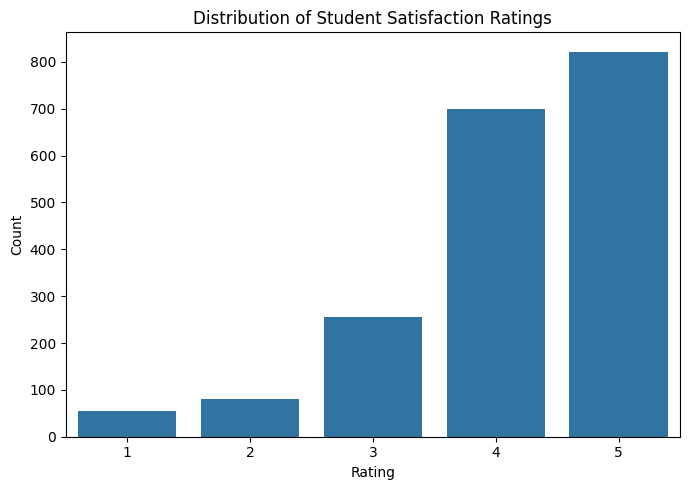

Saved: /content/recipe4u_genai_feedback_outputs/Figure_1_Rating_Distribution.png


In [11]:
# Cell 11 — Plot rating distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="rating_numeric", order=sorted(df_clean["rating_numeric"].dropna().unique()))
plt.title("Distribution of Student Satisfaction Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_1_Rating_Distribution.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

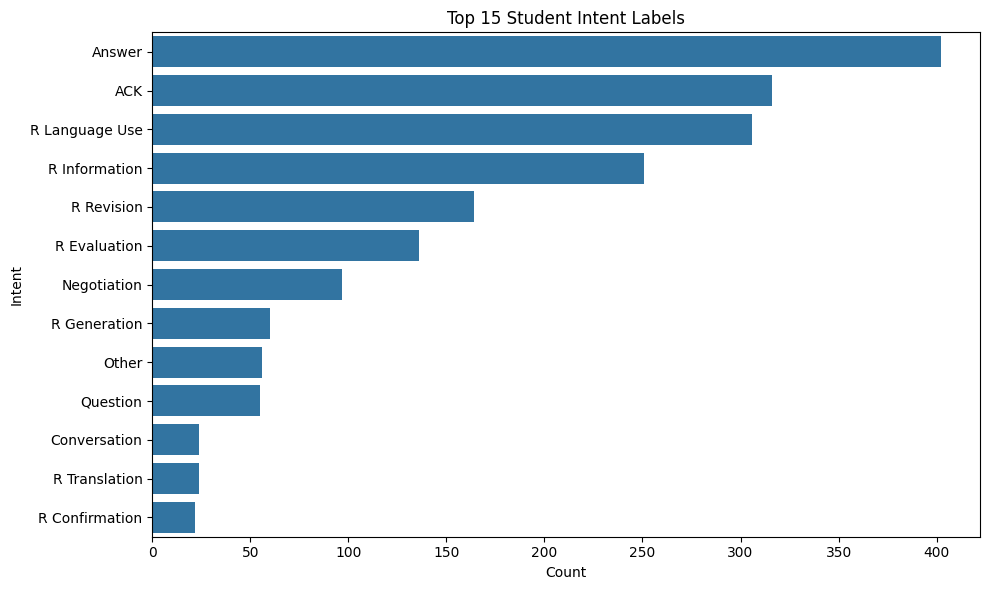

Saved: /content/recipe4u_genai_feedback_outputs/Figure_2_Top_Intent_Labels.png


In [12]:
#Cell 12 — Plot top intent labels


top_n = 15
top_intents = intent_dist.head(top_n)["intent_final"].tolist()

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean[df_clean["intent_final"].isin(top_intents)],
    y="intent_final",
    order=top_intents
)
plt.title(f"Top {top_n} Student Intent Labels")
plt.xlabel("Count")
plt.ylabel("Intent")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_2_Top_Intent_Labels.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [13]:
# Cell 13 — Define safe readability function

#This adapts your earlier readability work to chatgpt_after.

def safe_metric(func, text, default=np.nan):
    try:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return default
        return func(text)
    except Exception:
        return default


def compute_textstat_metrics(text):
    text = "" if pd.isna(text) else str(text)

    return {
        "flesch_reading_ease": safe_metric(textstat.flesch_reading_ease, text),
        "flesch_kincaid_grade": safe_metric(textstat.flesch_kincaid_grade, text),
        "smog_index": safe_metric(textstat.smog_index, text),
        "coleman_liau_index": safe_metric(textstat.coleman_liau_index, text),
        "automated_readability_index": safe_metric(textstat.automated_readability_index, text),
        "dale_chall_readability_score": safe_metric(textstat.dale_chall_readability_score, text),
        "difficult_words": safe_metric(textstat.difficult_words, text),
        "linsear_write_formula": safe_metric(textstat.linsear_write_formula, text),
        "gunning_fog": safe_metric(textstat.gunning_fog, text),
        "syllable_count": safe_metric(textstat.syllable_count, text),
        "lexicon_count": safe_metric(textstat.lexicon_count, text),
        "sentence_count": safe_metric(textstat.sentence_count, text),
        "char_count": safe_metric(textstat.char_count, text),
        "letter_count": safe_metric(textstat.letter_count, text),
        "polysyllabcount": safe_metric(textstat.polysyllabcount, text),
        "monosyllabcount": safe_metric(textstat.monosyllabcount, text),
        "reading_time": safe_metric(textstat.reading_time, text),
    }

In [14]:
# Cell 14 — Compute readability metrics for ChatGPT responses

# This may take a little time depending on number of rows.

response_metrics = []

for text in tqdm(df_clean["chatgpt_after"], desc="Computing ChatGPT response readability"):
    response_metrics.append(compute_textstat_metrics(text))

response_metrics_df = pd.DataFrame(response_metrics)
response_metrics_df = response_metrics_df.add_prefix("ai_")

df_metrics = pd.concat([df_clean.reset_index(drop=True), response_metrics_df.reset_index(drop=True)], axis=1)

print("Dataset with metrics:", df_metrics.shape)
df_metrics.head()

Computing ChatGPT response readability:   0%|          | 0/1913 [00:00<?, ?it/s]

Dataset with metrics: (1913, 39)


,sample_id,course,student_id,week,session,idx,chatgpt_before,user,chatgpt_after,rating,...,ai_linsear_write_formula,ai_gunning_fog,ai_syllable_count,ai_lexicon_count,ai_sentence_count,ai_char_count,ai_letter_count,ai_polysyllabcount,ai_monosyllabcount,ai_reading_time
0,9f45c512db-SW-1-1-01,SW,9f45c512db,1,1,1,Hello! Welcome to the main exercise. Can you p...,"Today, I learned about the comma rules. When t...","Yes, that's correct! Commas are an important t...",4,...,7.833333,12.500901,62,37,3,190,184,8,22,2.79110
1,9f45c512db-SW-1-1-02,SW,9f45c512db,1,1,2,"Yes, that's correct! Commas are an important t...","Ok. One example sentence might be:\n""Because I...","Great example! In this sentence, ""because I sk...",5,...,16.166667,15.461472,118,77,3,358,342,10,49,5.25902
2,9f45c512db-SW-1-1-03,SW,9f45c512db,1,1,3,"Great example! In this sentence, ""because I sk...",So can you help me to correct comma rules in m...,"Sure, I'd be happy to help you with that. Plea...",4,...,6.500000,8.276923,32,26,2,108,104,2,22,1.58652
3,9f45c512db-SW-1-1-04,SW,9f45c512db,1,1,4,"Sure, I'd be happy to help you with that. Plea...","Ok, my paragraph is:\n<para> In one sense, the...",I have identified a few spots where commas wou...,2,...,16.500000,12.837438,453,290,14,1414,1347,39,174,20.77166
4,9f45c512db-SW-1-1-05,SW,9f45c512db,1,1,5,I have identified a few spots where commas wou...,Maybe we need to define a clause first. A clau...,You are correct. I apologize for misleading yo...,2,...,11.500000,13.623529,279,170,10,844,821,30,102,12.39836


In [15]:
# Cell 15 — Compute readability metrics for student prompts

user_metrics = []

for text in tqdm(df_clean["user"], desc="Computing student prompt readability"):
    user_metrics.append(compute_textstat_metrics(text))

user_metrics_df = pd.DataFrame(user_metrics)
user_metrics_df = user_metrics_df.add_prefix("user_")

df_metrics = pd.concat([df_metrics.reset_index(drop=True), user_metrics_df.reset_index(drop=True)], axis=1)

print("Dataset with user and AI metrics:", df_metrics.shape)
df_metrics.head()

Computing student prompt readability:   0%|          | 0/1913 [00:00<?, ?it/s]

Dataset with user and AI metrics: (1913, 56)


,sample_id,course,student_id,week,session,idx,chatgpt_before,user,chatgpt_after,rating,...,user_linsear_write_formula,user_gunning_fog,user_syllable_count,user_lexicon_count,user_sentence_count,user_char_count,user_letter_count,user_polysyllabcount,user_monosyllabcount,user_reading_time
0,9f45c512db-SW-1-1-01,SW,9f45c512db,1,1,1,Hello! Welcome to the main exercise. Can you p...,"Today, I learned about the comma rules. When t...","Yes, that's correct! Commas are an important t...",4,...,6.000000,8.133333,34,24,2,108,104,2,17,1.58652
1,9f45c512db-SW-1-1-02,SW,9f45c512db,1,1,2,"Yes, that's correct! Commas are an important t...","Ok. One example sentence might be:\n""Because I...","Great example! In this sentence, ""because I sk...",5,...,8.500000,9.152941,25,17,1,75,70,1,10,1.10175
2,9f45c512db-SW-1-1-03,SW,9f45c512db,1,1,3,"Great example! In this sentence, ""because I sk...",So can you help me to correct comma rules in m...,"Sure, I'd be happy to help you with that. Plea...",4,...,6.000000,8.133333,16,12,1,47,46,1,9,0.69043
3,9f45c512db-SW-1-1-04,SW,9f45c512db,1,1,4,"Sure, I'd be happy to help you with that. Plea...","Ok, my paragraph is:\n<para> In one sense, the...",I have identified a few spots where commas wou...,2,...,7.857143,11.145455,199,132,8,610,579,15,84,8.96090
4,9f45c512db-SW-1-1-05,SW,9f45c512db,1,1,5,I have identified a few spots where commas wou...,Maybe we need to define a clause first. A clau...,You are correct. I apologize for misleading yo...,2,...,3.333333,3.200000,33,24,3,107,103,1,16,1.57183


In [16]:
# Cell 16 — Create feedback complexity and usability indicators

# Lower grade-level and lower fog generally indicate easier readability.
# Higher Flesch Reading Ease indicates easier readability.

df_metrics["ai_response_length_words"] = df_metrics["chatgpt_after_word_count"]
df_metrics["user_prompt_length_words"] = df_metrics["user_word_count"]

df_metrics["ai_readability_ease_z"] = StandardScaler().fit_transform(
    df_metrics[["ai_flesch_reading_ease"]].fillna(df_metrics["ai_flesch_reading_ease"].median())
)

# Complexity score: higher = more complex
complexity_cols = [
    "ai_flesch_kincaid_grade",
    "ai_smog_index",
    "ai_gunning_fog",
    "ai_automated_readability_index",
    "ai_dale_chall_readability_score",
    "ai_difficult_words",
    "ai_response_length_words"
]

complexity_input = df_metrics[complexity_cols].copy()
for col in complexity_cols:
    complexity_input[col] = complexity_input[col].fillna(complexity_input[col].median())

complexity_z = StandardScaler().fit_transform(complexity_input)
df_metrics["ai_linguistic_complexity_index"] = complexity_z.mean(axis=1)

# Simpler feedback utility proxy before GPT coding
df_metrics["simple_feedback_accessibility_index"] = (
    df_metrics["ai_readability_ease_z"] - df_metrics["ai_linguistic_complexity_index"]
)

df_metrics[[
    "chatgpt_after",
    "ai_flesch_reading_ease",
    "ai_flesch_kincaid_grade",
    "ai_gunning_fog",
    "ai_response_length_words",
    "ai_linguistic_complexity_index",
    "simple_feedback_accessibility_index"
]].head()

,chatgpt_after,ai_flesch_reading_ease,ai_flesch_kincaid_grade,ai_gunning_fog,ai_response_length_words,ai_linguistic_complexity_index,simple_feedback_accessibility_index
0,"Yes, that's correct! Commas are an important t...",52.554505,8.992973,12.500901,37,-0.268248,0.100327
1,"Great example! In this sentence, ""because I sk...",51.136580,12.503117,15.461472,77,0.205001,-0.444850
2,"Sure, I'd be happy to help you with that. Plea...",89.516923,4.003077,8.276923,26,-1.039922,2.747019
3,I have identified a few spots where commas wou...,53.658966,10.920985,12.837438,290,0.521525,-0.633419
4,You are correct. I apologize for misleading yo...,50.736471,10.405882,13.623529,170,0.323080,-0.583225


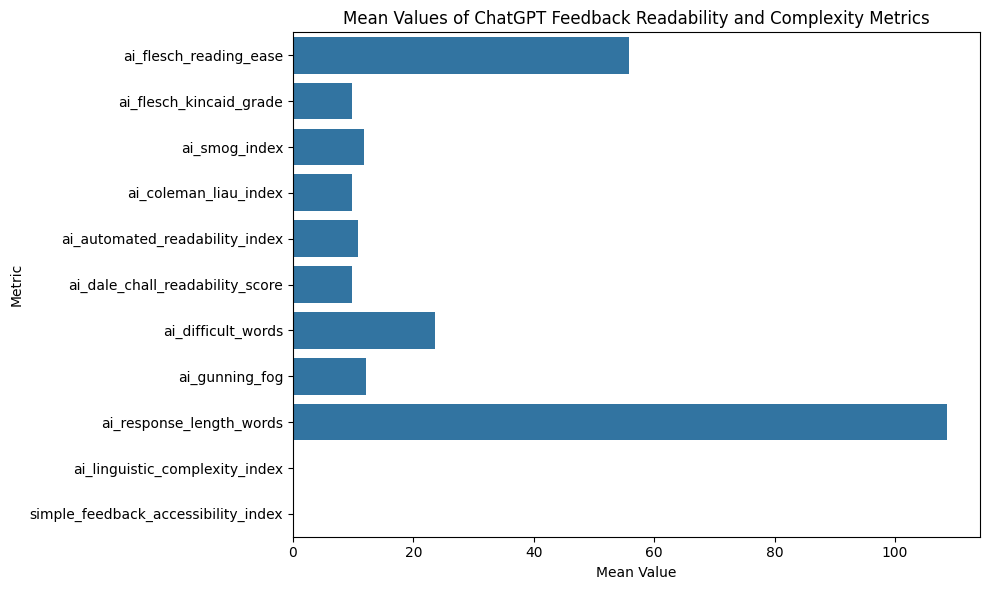

Saved: /content/recipe4u_genai_feedback_outputs/Figure_9_Readability_Descriptive_Means.png


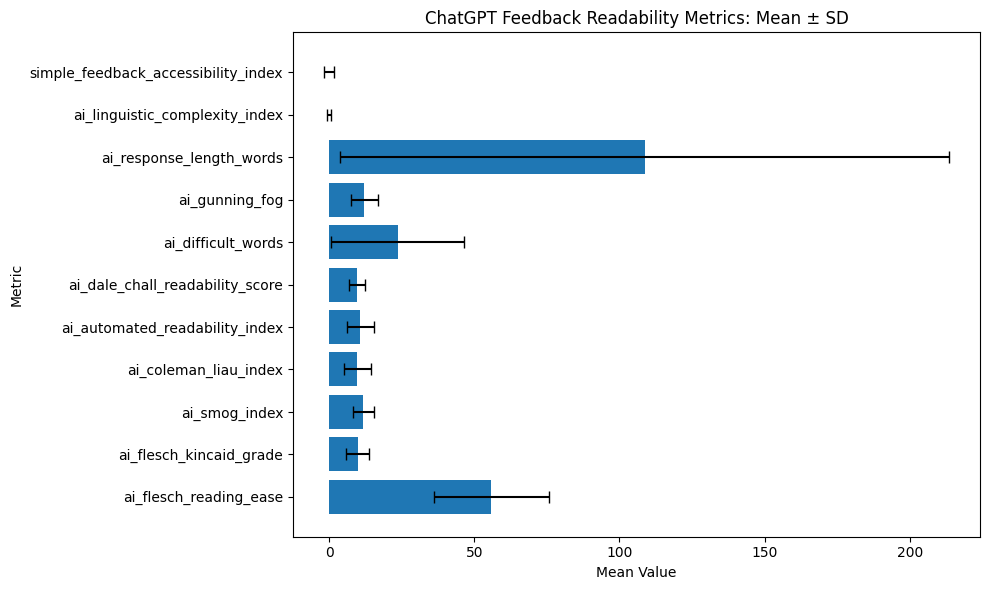

Saved: /content/recipe4u_genai_feedback_outputs/Figure_10_Readability_Descriptive_Means_SD.png

Descriptive Statistics for ChatGPT Feedback Readability and Complexity Metrics


,metric,count,mean,std,min,25%,50%,75%,max,missing
0,ai_flesch_reading_ease,1913.0,55.865,19.718,-48.852,42.397,55.041,68.567,117.668,0
1,ai_flesch_kincaid_grade,1913.0,9.788,3.873,-2.035,7.365,9.786,12.211,47.897,0
2,ai_smog_index,1913.0,11.812,3.692,3.129,9.889,12.162,14.233,28.030,0
3,ai_coleman_liau_index,1913.0,9.777,4.813,-16.400,7.973,10.509,12.471,20.006,0
4,ai_automated_readability_index,1913.0,10.750,4.601,-2.433,7.873,10.868,13.656,58.482,0
5,ai_dale_chall_readability_score,1913.0,9.736,2.725,0.149,8.248,9.524,10.685,20.402,0
6,ai_difficult_words,1913.0,23.610,22.789,0.000,5.000,18.000,34.000,215.000,0
7,ai_gunning_fog,1913.0,12.143,4.565,0.400,9.258,12.210,15.000,50.514,0
8,ai_response_length_words,1913.0,108.675,104.791,1.000,32.000,79.000,147.000,968.000,0
9,ai_linguistic_complexity_index,1913.0,-0.000,0.774,-2.097,-0.563,-0.013,0.516,5.073,0


Saved: /content/recipe4u_genai_feedback_outputs/Table_4_AI_Feedback_Readability_Descriptives.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_4b_AI_Feedback_Readability_Descriptives_Copy_Paste.xlsx


In [40]:
# Cell 17 — Descriptive statistics for readability metrics

readability_cols = [
    "ai_flesch_reading_ease",
    "ai_flesch_kincaid_grade",
    "ai_smog_index",
    "ai_coleman_liau_index",
    "ai_automated_readability_index",
    "ai_dale_chall_readability_score",
    "ai_difficult_words",
    "ai_gunning_fog",
    "ai_response_length_words",
    "ai_linguistic_complexity_index",
    "simple_feedback_accessibility_index"
]

readability_desc = df_metrics[readability_cols].describe().T
readability_desc["missing"] = df_metrics[readability_cols].isna().sum()
readability_desc = readability_desc.round(3)

# ---- Plot first ----

readability_plot_df = readability_desc.reset_index().rename(columns={"index": "metric"})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=readability_plot_df,
    y="metric",
    x="mean"
)

plt.title("Mean Values of ChatGPT Feedback Readability and Complexity Metrics")
plt.xlabel("Mean Value")
plt.ylabel("Metric")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_9_Readability_Descriptive_Means.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# Optional second plot: mean with standard deviation error bars

plt.figure(figsize=(10, 6))
plt.barh(
    y=readability_plot_df["metric"],
    width=readability_plot_df["mean"],
    xerr=readability_plot_df["std"],
    capsize=4
)

plt.title("ChatGPT Feedback Readability Metrics: Mean ± SD")
plt.xlabel("Mean Value")
plt.ylabel("Metric")
plt.tight_layout()

fig_path_sd = OUTPUT_DIR / "Figure_10_Readability_Descriptive_Means_SD.png"
plt.savefig(fig_path_sd, dpi=300)
plt.show()

print("Saved:", fig_path_sd)

# ---- Then print/display tabular values ----

readability_desc_path = OUTPUT_DIR / "Table_4_AI_Feedback_Readability_Descriptives.xlsx"
readability_desc.to_excel(readability_desc_path)

readability_desc_copy = readability_desc.reset_index().rename(columns={"index": "metric"})

readability_desc_copy_path = OUTPUT_DIR / "Table_4b_AI_Feedback_Readability_Descriptives_Copy_Paste.xlsx"
readability_desc_copy.to_excel(readability_desc_copy_path, index=False)

print("\nDescriptive Statistics for ChatGPT Feedback Readability and Complexity Metrics")
display(readability_desc_copy)

print("Saved:", readability_desc_path)
print("Saved:", readability_desc_copy_path)

In [19]:
# Cell 18 — Compare edited vs non-edited cases

group_compare_vars = readability_cols + [
    "rating_numeric",
    "user_prompt_length_words"
]

comparison_rows = []

for var in group_compare_vars:
    edited = df_metrics.loc[df_metrics["essay_edited_binary"] == 1, var].dropna()
    not_edited = df_metrics.loc[df_metrics["essay_edited_binary"] == 0, var].dropna()

    if len(edited) > 2 and len(not_edited) > 2:
        u_stat, p_val = mannwhitneyu(edited, not_edited, alternative="two-sided")

        comparison_rows.append({
            "variable": var,
            "edited_mean": edited.mean(),
            "edited_sd": edited.std(),
            "not_edited_mean": not_edited.mean(),
            "not_edited_sd": not_edited.std(),
            "mann_whitney_u": u_stat,
            "p_value": p_val
        })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table["p_value_fdr"] = multipletests(comparison_table["p_value"], method="fdr_bh")[1]
comparison_table = comparison_table.round(4)

comparison_path = OUTPUT_DIR / "Table_5_Edited_vs_Not_Edited_Comparison.xlsx"
comparison_table.to_excel(comparison_path, index=False)

display(comparison_table)
print("Saved:", comparison_path)




,variable,edited_mean,edited_sd,not_edited_mean,not_edited_sd,mann_whitney_u,p_value,p_value_fdr
0,ai_flesch_reading_ease,52.2935,19.2292,56.6672,19.7438,241966.0,0.0006,0.0006
1,ai_flesch_kincaid_grade,10.5715,3.8158,9.6120,3.8651,314453.0,0.0000,0.0000
2,ai_smog_index,12.7812,3.2501,11.5943,3.7509,320740.0,0.0000,0.0000
3,ai_coleman_liau_index,10.9469,3.1926,9.5146,5.0712,319050.5,0.0000,0.0000
4,ai_automated_readability_index,11.8985,4.4042,10.4921,4.6064,323546.5,0.0000,0.0000
5,ai_dale_chall_readability_score,9.9543,2.1703,9.6864,2.8335,311663.5,0.0001,0.0001
6,ai_difficult_words,34.4986,26.5079,21.1626,21.1161,362362.5,0.0000,0.0000
7,ai_gunning_fog,13.2282,4.1731,11.8989,4.6142,318608.0,0.0000,0.0000
8,ai_response_length_words,165.1339,132.0971,95.9885,93.0597,368120.5,0.0000,0.0000
9,ai_linguistic_complexity_index,0.2928,0.7523,-0.0658,0.7634,349270.5,0.0000,0.0000


Saved: /content/recipe4u_genai_feedback_outputs/Table_5_Edited_vs_Not_Edited_Comparison.xlsx


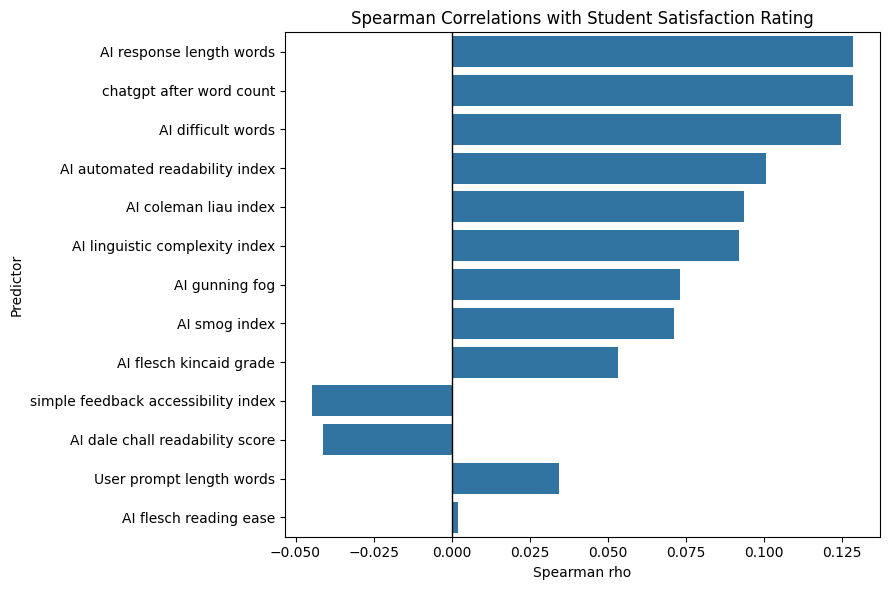

Saved: /content/recipe4u_genai_feedback_outputs/Figure_8_Correlations_With_Satisfaction_Rating.png

Correlation of Feedback Readability and Interaction Metrics with Satisfaction Rating


,predictor,outcome,spearman_rho,p_value,n,p_value_fdr,significance_fdr
0,ai_response_length_words,rating_numeric,0.1286,0.0000,1913,0.0000,***
1,chatgpt_after_word_count,rating_numeric,0.1286,0.0000,1913,0.0000,***
2,ai_difficult_words,rating_numeric,0.1248,0.0000,1913,0.0000,***
3,ai_automated_readability_index,rating_numeric,0.1006,0.0000,1913,0.0000,***
4,ai_coleman_liau_index,rating_numeric,0.0936,0.0000,1913,0.0001,***
5,ai_linguistic_complexity_index,rating_numeric,0.0921,0.0001,1913,0.0001,***
6,ai_gunning_fog,rating_numeric,0.0733,0.0013,1913,0.0025,**
7,ai_smog_index,rating_numeric,0.0712,0.0018,1913,0.0030,**
8,ai_flesch_kincaid_grade,rating_numeric,0.0532,0.0199,1913,0.0287,*
9,simple_feedback_accessibility_index,rating_numeric,-0.0447,0.0504,1913,0.0655,ns


Saved: /content/recipe4u_genai_feedback_outputs/Table_6_Readability_Correlation_With_Rating.xlsx


In [39]:
# Cell 19 — Correlation with satisfaction rating

# *** p < .001
# **  p < .01
# *   p < .05
# ns  not significant

corr_rows = []

for var in readability_cols + ["user_prompt_length_words", "chatgpt_after_word_count"]:
    temp = df_metrics[[var, "rating_numeric"]].dropna()

    if len(temp) > 3:
        rho, p = spearmanr(temp[var], temp["rating_numeric"])
        corr_rows.append({
            "predictor": var,
            "outcome": "rating_numeric",
            "spearman_rho": rho,
            "p_value": p,
            "n": len(temp)
        })

rating_corr_table = pd.DataFrame(corr_rows)

rating_corr_table["p_value_fdr"] = multipletests(
    rating_corr_table["p_value"],
    method="fdr_bh"
)[1]

rating_corr_table = rating_corr_table.round(4)

# Add significance labels
def significance_label(p):
    if pd.isna(p):
        return "NA"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

rating_corr_table["significance_fdr"] = rating_corr_table["p_value_fdr"].apply(significance_label)

# Sort by absolute correlation strength
rating_corr_table = (
    rating_corr_table
    .assign(abs_spearman_rho=rating_corr_table["spearman_rho"].abs())
    .sort_values("abs_spearman_rho", ascending=False)
    .drop(columns="abs_spearman_rho")
    .reset_index(drop=True)
)

# ---- Plot first ----

plot_df = rating_corr_table.copy()
plot_df["predictor_clean"] = (
    plot_df["predictor"]
    .str.replace("_", " ", regex=False)
    .str.replace("ai ", "AI ", regex=False)
    .str.replace("user ", "User ", regex=False)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=plot_df,
    y="predictor_clean",
    x="spearman_rho"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Spearman Correlations with Student Satisfaction Rating")
plt.xlabel("Spearman rho")
plt.ylabel("Predictor")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_8_Correlations_With_Satisfaction_Rating.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print/display tabular values ----

rating_corr_path = OUTPUT_DIR / "Table_6_Readability_Correlation_With_Rating.xlsx"
rating_corr_table.to_excel(rating_corr_path, index=False)

print("\nCorrelation of Feedback Readability and Interaction Metrics with Satisfaction Rating")
display(rating_corr_table)

print("Saved:", rating_corr_path)

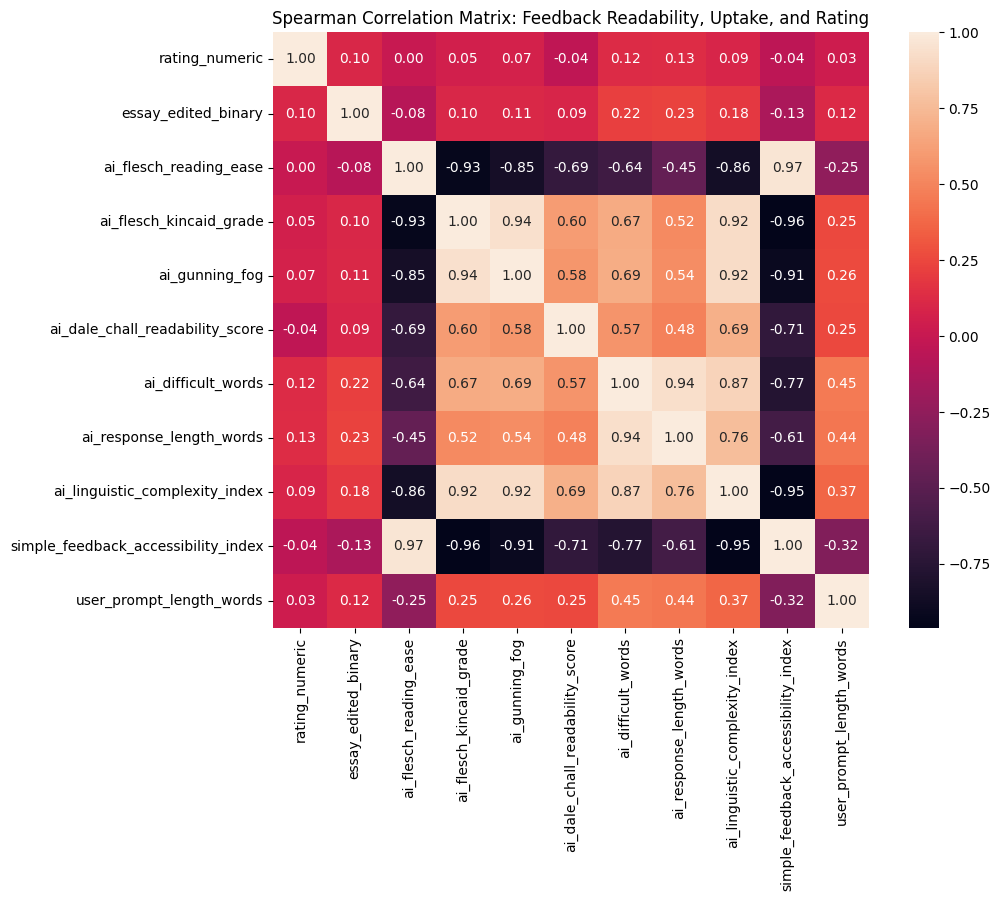

Saved: /content/recipe4u_genai_feedback_outputs/Figure_3_Correlation_Heatmap.png

Spearman Correlation Matrix


,rating_numeric,essay_edited_binary,ai_flesch_reading_ease,ai_flesch_kincaid_grade,ai_gunning_fog,ai_dale_chall_readability_score,ai_difficult_words,ai_response_length_words,ai_linguistic_complexity_index,simple_feedback_accessibility_index,user_prompt_length_words
rating_numeric,1.000,0.102,0.002,0.053,0.073,-0.041,0.125,0.129,0.092,-0.045,0.034
essay_edited_binary,0.102,1.000,-0.079,0.099,0.109,0.092,0.216,0.230,0.184,-0.133,0.115
ai_flesch_reading_ease,0.002,-0.079,1.000,-0.931,-0.851,-0.690,-0.636,-0.451,-0.856,0.969,-0.251
ai_flesch_kincaid_grade,0.053,0.099,-0.931,1.000,0.945,0.604,0.674,0.522,0.917,-0.960,0.250
ai_gunning_fog,0.073,0.109,-0.851,0.945,1.000,0.576,0.685,0.539,0.921,-0.914,0.261
ai_dale_chall_readability_score,-0.041,0.092,-0.690,0.604,0.576,1.000,0.568,0.484,0.695,-0.707,0.253
ai_difficult_words,0.125,0.216,-0.636,0.674,0.685,0.568,1.000,0.935,0.872,-0.771,0.453
ai_response_length_words,0.129,0.230,-0.451,0.522,0.539,0.484,0.935,1.000,0.763,-0.611,0.438
ai_linguistic_complexity_index,0.092,0.184,-0.856,0.917,0.921,0.695,0.872,0.763,1.000,-0.954,0.367
simple_feedback_accessibility_index,-0.045,-0.133,0.969,-0.960,-0.914,-0.707,-0.771,-0.611,-0.954,1.000,-0.317



Spearman Correlation Matrix in Long Format


,variable_1,variable_2,spearman_correlation
0,simple_feedback_accessibility_index,ai_flesch_reading_ease,0.969
1,simple_feedback_accessibility_index,ai_flesch_kincaid_grade,-0.960
2,simple_feedback_accessibility_index,ai_linguistic_complexity_index,-0.954
3,ai_gunning_fog,ai_flesch_kincaid_grade,0.945
4,ai_response_length_words,ai_difficult_words,0.935
5,ai_flesch_kincaid_grade,ai_flesch_reading_ease,-0.931
6,ai_linguistic_complexity_index,ai_gunning_fog,0.921
7,ai_linguistic_complexity_index,ai_flesch_kincaid_grade,0.917
8,simple_feedback_accessibility_index,ai_gunning_fog,-0.914
9,ai_linguistic_complexity_index,ai_difficult_words,0.872


Saved: /content/recipe4u_genai_feedback_outputs/Table_7_Correlation_Matrix.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_7b_Correlation_Matrix_Long_Format.xlsx


In [38]:
# Cell 20 — Correlation heatmap

heatmap_vars = [
    "rating_numeric",
    "essay_edited_binary",
    "ai_flesch_reading_ease",
    "ai_flesch_kincaid_grade",
    "ai_gunning_fog",
    "ai_dale_chall_readability_score",
    "ai_difficult_words",
    "ai_response_length_words",
    "ai_linguistic_complexity_index",
    "simple_feedback_accessibility_index",
    "user_prompt_length_words"
]

corr_matrix = df_metrics[heatmap_vars].corr(method="spearman").round(3)

# ---- Plot first ----

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=True
)
plt.title("Spearman Correlation Matrix: Feedback Readability, Uptake, and Rating")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_3_Correlation_Heatmap.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print/display tabular values ----

corr_path = OUTPUT_DIR / "Table_7_Correlation_Matrix.xlsx"
corr_matrix.to_excel(corr_path)

# Long-format copy-pasteable correlation table
corr_long = (
    corr_matrix
    .reset_index()
    .melt(
        id_vars="index",
        var_name="variable_2",
        value_name="spearman_correlation"
    )
    .rename(columns={"index": "variable_1"})
)

# Remove duplicate symmetric entries and self-correlations
corr_long["pair_key"] = corr_long.apply(
    lambda row: " | ".join(sorted([row["variable_1"], row["variable_2"]])),
    axis=1
)

corr_long_unique = (
    corr_long[
        corr_long["variable_1"] != corr_long["variable_2"]
    ]
    .drop_duplicates(subset="pair_key")
    .drop(columns="pair_key")
    .sort_values("spearman_correlation", key=lambda x: x.abs(), ascending=False)
    .reset_index(drop=True)
)

corr_long_path = OUTPUT_DIR / "Table_7b_Correlation_Matrix_Long_Format.xlsx"
corr_long_unique.to_excel(corr_long_path, index=False)

print("\nSpearman Correlation Matrix")
display(corr_matrix)

print("\nSpearman Correlation Matrix in Long Format")
display(corr_long_unique)

print("Saved:", corr_path)
print("Saved:", corr_long_path)

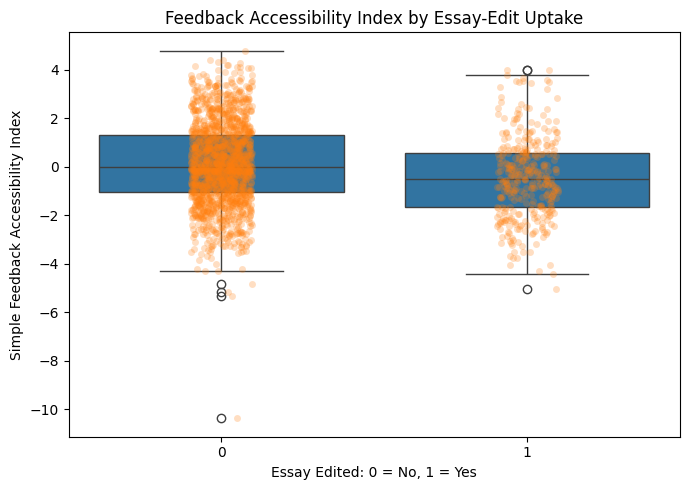

Saved: /content/recipe4u_genai_feedback_outputs/Figure_4_Feedback_Accessibility_by_Essay_Edit.png

Feedback Accessibility Index by Essay-Edit Uptake


,essay_edited_binary,essay_edit_status,n,mean_feedback_accessibility,sd_feedback_accessibility,median_feedback_accessibility,min_feedback_accessibility,q1_feedback_accessibility,q3_feedback_accessibility,max_feedback_accessibility
0,0,Not edited,1562,0.1065,1.7011,-0.0097,-10.3850,-1.0490,1.2858,4.7775
1,1,Edited,351,-0.4740,1.6622,-0.5256,-5.0311,-1.6855,0.5441,3.9871


Saved: /content/recipe4u_genai_feedback_outputs/Table_17_Feedback_Accessibility_by_Essay_Edit.xlsx


In [37]:
# Cell 21 — Boxplot: feedback accessibility by essay-edit status

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_metrics,
    x="essay_edited_binary",
    y="simple_feedback_accessibility_index"
)
sns.stripplot(
    data=df_metrics,
    x="essay_edited_binary",
    y="simple_feedback_accessibility_index",
    alpha=0.25
)
plt.title("Feedback Accessibility Index by Essay-Edit Uptake")
plt.xlabel("Essay Edited: 0 = No, 1 = Yes")
plt.ylabel("Simple Feedback Accessibility Index")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_4_Feedback_Accessibility_by_Essay_Edit.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Copy-pasteable tabular values below the plot ----

feedback_accessibility_summary = (
    df_metrics
    .groupby("essay_edited_binary")
    .agg(
        n=("simple_feedback_accessibility_index", "count"),
        mean_feedback_accessibility=("simple_feedback_accessibility_index", "mean"),
        sd_feedback_accessibility=("simple_feedback_accessibility_index", "std"),
        median_feedback_accessibility=("simple_feedback_accessibility_index", "median"),
        min_feedback_accessibility=("simple_feedback_accessibility_index", "min"),
        q1_feedback_accessibility=("simple_feedback_accessibility_index", lambda x: x.quantile(0.25)),
        q3_feedback_accessibility=("simple_feedback_accessibility_index", lambda x: x.quantile(0.75)),
        max_feedback_accessibility=("simple_feedback_accessibility_index", "max")
    )
    .reset_index()
    .round(4)
)

feedback_accessibility_summary["essay_edit_status"] = feedback_accessibility_summary[
    "essay_edited_binary"
].map({
    0: "Not edited",
    1: "Edited"
})

feedback_accessibility_summary = feedback_accessibility_summary[
    [
        "essay_edited_binary",
        "essay_edit_status",
        "n",
        "mean_feedback_accessibility",
        "sd_feedback_accessibility",
        "median_feedback_accessibility",
        "min_feedback_accessibility",
        "q1_feedback_accessibility",
        "q3_feedback_accessibility",
        "max_feedback_accessibility"
    ]
]

feedback_accessibility_table_path = OUTPUT_DIR / "Table_17_Feedback_Accessibility_by_Essay_Edit.xlsx"
feedback_accessibility_summary.to_excel(feedback_accessibility_table_path, index=False)

print("\nFeedback Accessibility Index by Essay-Edit Uptake")
display(feedback_accessibility_summary)

print("Saved:", feedback_accessibility_table_path)

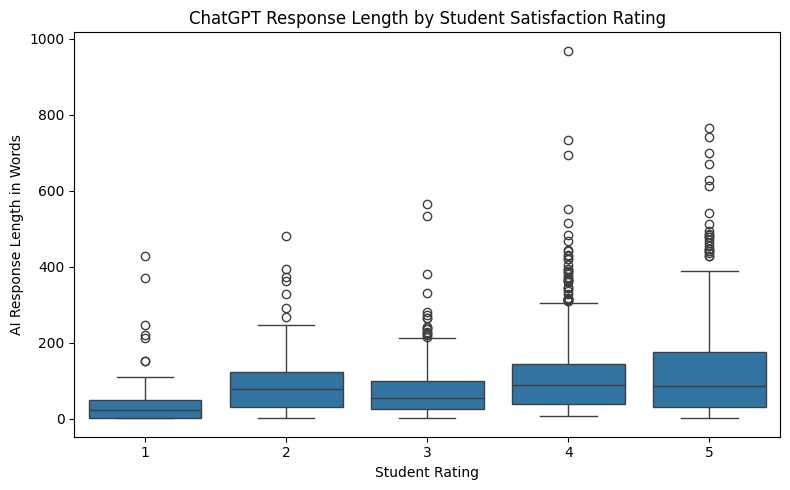

Saved: /content/recipe4u_genai_feedback_outputs/Figure_5_Response_Length_by_Rating.png


In [23]:
# Cell 22 — Boxplot: AI response length by rating

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_metrics, x="rating_numeric", y="ai_response_length_words")
plt.title("ChatGPT Response Length by Student Satisfaction Rating")
plt.xlabel("Student Rating")
plt.ylabel("AI Response Length in Words")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_5_Response_Length_by_Rating.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [24]:
# Cell 23 — Intent-wise satisfaction and edit uptake

intent_summary = (
    df_metrics
    .groupby("intent_final")
    .agg(
        n=("sample_id", "count"),
        mean_rating=("rating_numeric", "mean"),
        sd_rating=("rating_numeric", "std"),
        essay_edit_rate=("essay_edited_binary", "mean"),
        mean_ai_words=("ai_response_length_words", "mean"),
        mean_ai_flesch=("ai_flesch_reading_ease", "mean"),
        mean_ai_complexity=("ai_linguistic_complexity_index", "mean")
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

intent_summary = intent_summary.round(4)

intent_summary_path = OUTPUT_DIR / "Table_8_Intent_Wise_Outcomes.xlsx"
intent_summary.to_excel(intent_summary_path, index=False)

display(intent_summary.head(30))
print("Saved:", intent_summary_path)

,intent_final,n,mean_rating,sd_rating,essay_edit_rate,mean_ai_words,mean_ai_flesch,mean_ai_complexity
1,Answer,402,4.1294,0.8951,0.1343,71.9801,59.0140,-0.2781
0,ACK,316,4.4114,0.8018,0.2089,125.7152,59.2657,-0.1050
10,R Language Use,306,4.1340,0.9607,0.2255,102.5915,60.0564,-0.1423
9,R Information,251,4.1753,0.9472,0.1315,136.7291,44.9501,0.4411
11,R Revision,164,4.0488,1.0261,0.2988,144.6585,50.1212,0.3694
7,R Evaluation,136,3.9706,1.1349,0.1471,90.7868,61.5329,-0.1145
3,Negotiation,97,3.8866,1.1169,0.1856,123.5773,50.2965,0.2470
8,R Generation,60,4.0667,1.0715,0.3333,157.3500,42.3417,0.6532
4,Other,56,4.1786,0.9928,0.1607,146.9286,52.2918,0.1680
5,Question,55,3.6000,1.2263,0.0727,82.2364,58.0530,-0.1072


Saved: /content/recipe4u_genai_feedback_outputs/Table_8_Intent_Wise_Outcomes.xlsx


In [25]:
# Cell 24 — Logistic regression: predicting essay-edit uptake

# This model tests whether feedback readability and complexity relate to actual uptake.

model_df = df_metrics[[
    "essay_edited_binary",
    "ai_flesch_reading_ease",
    "ai_flesch_kincaid_grade",
    "ai_gunning_fog",
    "ai_response_length_words",
    "ai_linguistic_complexity_index",
    "user_prompt_length_words",
    "rating_numeric",
    "intent_final"
]].dropna()

# To reduce extreme scale effects
model_df["log_ai_words"] = np.log1p(model_df["ai_response_length_words"])
model_df["log_user_words"] = np.log1p(model_df["user_prompt_length_words"])

# Use top intents and group rare intents as Other
top_intents_for_model = model_df["intent_final"].value_counts().head(10).index
model_df["intent_model"] = np.where(
    model_df["intent_final"].isin(top_intents_for_model),
    model_df["intent_final"],
    "Other"
)

logit_formula = """
essay_edited_binary ~
ai_flesch_reading_ease +
ai_flesch_kincaid_grade +
ai_gunning_fog +
log_ai_words +
log_user_words +
rating_numeric +
C(intent_model)
"""

logit_model = smf.logit(logit_formula, data=model_df).fit(maxiter=200)

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.435724
         Iterations 7
                            Logit Regression Results                           
Dep. Variable:     essay_edited_binary   No. Observations:                 1913
Model:                           Logit   Df Residuals:                     1897
Method:                            MLE   Df Model:                           15
Date:                 Mon, 18 May 2026   Pseudo R-squ.:                 0.08583
Time:                         12:57:43   Log-Likelihood:                -833.54
converged:                        True   LL-Null:                       -911.80
Covariance Type:             nonrobust   LLR p-value:                 1.219e-25
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -5.1021      1.21

In [26]:
# Cell 25 — Export logistic regression table

logit_params = logit_model.params
logit_conf = logit_model.conf_int()
logit_p = logit_model.pvalues

logit_table = pd.DataFrame({
    "term": logit_params.index,
    "coef_log_odds": logit_params.values,
    "odds_ratio": np.exp(logit_params.values),
    "ci_lower_or": np.exp(logit_conf[0].values),
    "ci_upper_or": np.exp(logit_conf[1].values),
    "p_value": logit_p.values
}).round(4)

logit_table_path = OUTPUT_DIR / "Table_9_Logistic_Regression_Essay_Edit_Uptake.xlsx"
logit_table.to_excel(logit_table_path, index=False)

display(logit_table)
print("Saved:", logit_table_path)

,term,coef_log_odds,odds_ratio,ci_lower_or,ci_upper_or,p_value
0,Intercept,-5.1021,0.0061,0.0006,0.0662,0.0000
1,C(intent_model)[T.Answer],-0.2503,0.7786,0.5077,1.1941,0.2514
2,C(intent_model)[T.Negotiation],-0.1285,0.8794,0.4714,1.6408,0.6864
3,C(intent_model)[T.Other],-0.2168,0.8051,0.4415,1.4679,0.4793
4,C(intent_model)[T.Question],-0.8784,0.4155,0.1404,1.2298,0.1126
5,C(intent_model)[T.R Evaluation],-0.2598,0.7712,0.4345,1.3690,0.3750
6,C(intent_model)[T.R Generation],0.5622,1.7546,0.9041,3.4051,0.0965
7,C(intent_model)[T.R Information],-0.7147,0.4893,0.2941,0.8140,0.0059
8,C(intent_model)[T.R Language Use],0.2298,1.2583,0.8313,1.9047,0.2773
9,C(intent_model)[T.R Revision],0.4220,1.5249,0.9542,2.4370,0.0777


Saved: /content/recipe4u_genai_feedback_outputs/Table_9_Logistic_Regression_Essay_Edit_Uptake.xlsx


In [27]:
# Cell 26 — Linear regression: predicting satisfaction rating

rating_model_df = df_metrics[[
    "rating_numeric",
    "ai_flesch_reading_ease",
    "ai_flesch_kincaid_grade",
    "ai_gunning_fog",
    "ai_response_length_words",
    "ai_linguistic_complexity_index",
    "user_prompt_length_words",
    "essay_edited_binary",
    "intent_final"
]].dropna()

rating_model_df["log_ai_words"] = np.log1p(rating_model_df["ai_response_length_words"])
rating_model_df["log_user_words"] = np.log1p(rating_model_df["user_prompt_length_words"])

top_intents_for_rating = rating_model_df["intent_final"].value_counts().head(10).index
rating_model_df["intent_model"] = np.where(
    rating_model_df["intent_final"].isin(top_intents_for_rating),
    rating_model_df["intent_final"],
    "Other"
)

rating_formula = """
rating_numeric ~
ai_flesch_reading_ease +
ai_flesch_kincaid_grade +
ai_gunning_fog +
log_ai_words +
log_user_words +
essay_edited_binary +
C(intent_model)
"""

rating_model = smf.ols(rating_formula, data=rating_model_df).fit(cov_type="HC3")

print(rating_model.summary())

                            OLS Regression Results                            
Dep. Variable:         rating_numeric   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     13.02
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.14e-31
Time:                        12:58:10   Log-Likelihood:                -2571.3
No. Observations:                1913   AIC:                             5175.
Df Residuals:                    1897   BIC:                             5263.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [28]:
# Cell 27 — Export satisfaction regression table

rating_reg_table = pd.DataFrame({
    "term": rating_model.params.index,
    "coef": rating_model.params.values,
    "std_error": rating_model.bse.values,
    "t": rating_model.tvalues.values,
    "p_value": rating_model.pvalues.values,
    "ci_lower": rating_model.conf_int()[0].values,
    "ci_upper": rating_model.conf_int()[1].values
}).round(4)

rating_reg_path = OUTPUT_DIR / "Table_10_OLS_Regression_Satisfaction_Rating.xlsx"
rating_reg_table.to_excel(rating_reg_path, index=False)

display(rating_reg_table)
print("Saved:", rating_reg_path)

,term,coef,std_error,t,p_value,ci_lower,ci_upper
0,Intercept,2.4577,0.3758,6.5403,0.0000,1.7212,3.1943
1,C(intent_model)[T.Answer],-0.2367,0.0636,-3.7207,0.0002,-0.3615,-0.1120
2,C(intent_model)[T.Negotiation],-0.6716,0.1275,-5.2690,0.0000,-0.9215,-0.4218
3,C(intent_model)[T.Other],-0.3729,0.1067,-3.4954,0.0005,-0.5819,-0.1638
4,C(intent_model)[T.Question],-0.8325,0.1668,-4.9894,0.0000,-1.1595,-0.5055
5,C(intent_model)[T.R Evaluation],-0.4560,0.0995,-4.5808,0.0000,-0.6511,-0.2609
6,C(intent_model)[T.R Generation],-0.5209,0.1445,-3.6037,0.0003,-0.8041,-0.2376
7,C(intent_model)[T.R Information],-0.3652,0.0820,-4.4542,0.0000,-0.5259,-0.2045
8,C(intent_model)[T.R Language Use],-0.3337,0.0706,-4.7240,0.0000,-0.4722,-0.1953
9,C(intent_model)[T.R Revision],-0.4977,0.0919,-5.4168,0.0000,-0.6778,-0.3176


Saved: /content/recipe4u_genai_feedback_outputs/Table_10_OLS_Regression_Satisfaction_Rating.xlsx


In [29]:
# Cell 28 — Student-level aggregation

# This is important because rows are repeated interactions.


student_level = (
    df_metrics
    .groupby("student_id")
    .agg(
        n_interactions=("sample_id", "count"),
        mean_rating=("rating_numeric", "mean"),
        edit_rate=("essay_edited_binary", "mean"),
        mean_user_words=("user_prompt_length_words", "mean"),
        mean_ai_words=("ai_response_length_words", "mean"),
        mean_ai_flesch=("ai_flesch_reading_ease", "mean"),
        mean_ai_fk_grade=("ai_flesch_kincaid_grade", "mean"),
        mean_ai_gunning_fog=("ai_gunning_fog", "mean"),
        mean_ai_complexity=("ai_linguistic_complexity_index", "mean"),
        mean_feedback_accessibility=("simple_feedback_accessibility_index", "mean"),
        n_intents=("intent_final", "nunique")
    )
    .reset_index()
)

student_level_path = OUTPUT_DIR / "Table_11_Student_Level_Aggregation.xlsx"
student_level.to_excel(student_level_path, index=False)

display(student_level.head())
print("Saved:", student_level_path)

,student_id,n_interactions,mean_rating,edit_rate,mean_user_words,mean_ai_words,mean_ai_flesch,mean_ai_fk_grade,mean_ai_gunning_fog,mean_ai_complexity,mean_feedback_accessibility,n_intents
0,037016a822,3,4.000000,0.333333,118.666667,177.333333,58.412662,8.881098,10.816599,0.068692,0.060559,2
1,03bc4d0231,13,5.000000,0.000000,19.692308,50.153846,58.570963,8.915006,10.573590,-0.339658,0.476938,2
2,09a288d929,13,4.076923,0.384615,7.384615,111.230769,59.875576,9.689174,12.277304,-0.057918,0.261379,3
3,0b0865942e,14,4.500000,0.428571,103.142857,136.714286,62.213819,8.659045,11.541226,-0.064013,0.386087,5
4,0ca432e0ad,11,2.636364,0.000000,71.909091,102.727273,44.532325,12.320423,15.320899,0.412538,-0.987405,5


Saved: /content/recipe4u_genai_feedback_outputs/Table_11_Student_Level_Aggregation.xlsx


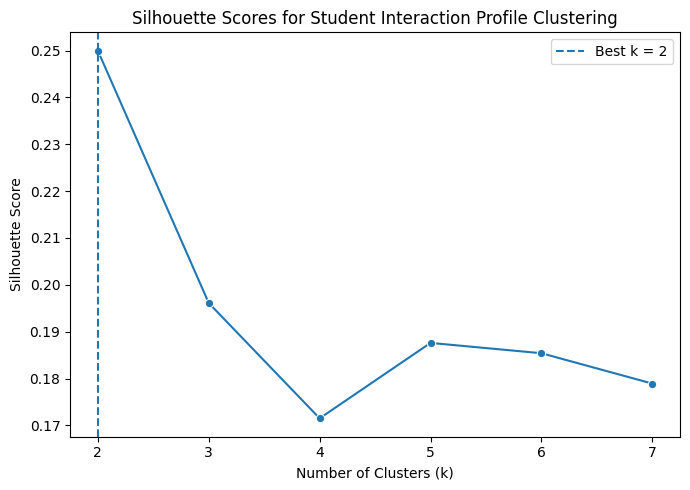

Saved: /content/recipe4u_genai_feedback_outputs/Figure_7_Silhouette_Scores_Student_Clusters.png

Best number of clusters selected: 2

Silhouette Scores by Number of Clusters


,k,silhouette_score
0,2,0.2500
1,3,0.1961
2,4,0.1715
3,5,0.1876
4,6,0.1854
5,7,0.1789



Cluster-wise Student Interaction Profile Summary


,interaction_profile_cluster,n_students,n_interactions,mean_rating,edit_rate,mean_user_words,mean_ai_words,mean_ai_flesch,mean_ai_complexity,mean_feedback_accessibility,n_intents
0,0,42,21.071,4.129,0.271,117.535,159.237,49.249,0.342,-0.678,5.810
1,1,88,11.682,3.965,0.172,57.258,89.577,61.443,-0.235,0.518,4.034


Saved: /content/recipe4u_genai_feedback_outputs/Table_12_Student_Interaction_Profile_Clusters.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_13_Cluster_Silhouette_Scores.xlsx


In [36]:
# Cell 29 — Cluster students into interaction profiles

cluster_features = [
    "n_interactions",
    "mean_rating",
    "edit_rate",
    "mean_user_words",
    "mean_ai_words",
    "mean_ai_flesch",
    "mean_ai_complexity",
    "mean_feedback_accessibility",
    "n_intents"
]

cluster_df = student_level.dropna(subset=cluster_features).copy()

X = cluster_df[cluster_features].copy()
X_scaled = StandardScaler().fit_transform(X)

silhouette_rows = []

for k in range(2, min(8, len(cluster_df))):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_rows.append({
        "k": k,
        "silhouette_score": sil
    })

silhouette_table = pd.DataFrame(silhouette_rows)

best_k = int(
    silhouette_table
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]["k"]
)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
cluster_df["interaction_profile_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    cluster_df
    .groupby("interaction_profile_cluster")[cluster_features]
    .mean()
    .round(3)
)

cluster_counts = (
    cluster_df["interaction_profile_cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = [
    "interaction_profile_cluster",
    "n_students"
]

cluster_summary_with_counts = (
    cluster_summary
    .reset_index()
    .merge(cluster_counts, on="interaction_profile_cluster", how="left")
)

cluster_summary_with_counts = cluster_summary_with_counts[
    ["interaction_profile_cluster", "n_students"] + cluster_features
].round(3)

cluster_summary_path = OUTPUT_DIR / "Table_12_Student_Interaction_Profile_Clusters.xlsx"
cluster_summary_with_counts.to_excel(cluster_summary_path, index=False)

silhouette_path = OUTPUT_DIR / "Table_13_Cluster_Silhouette_Scores.xlsx"
silhouette_table.to_excel(silhouette_path, index=False)

# ---- Plot first ----

plt.figure(figsize=(7, 5))
sns.lineplot(
    data=silhouette_table,
    x="k",
    y="silhouette_score",
    marker="o"
)
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")
plt.title("Silhouette Scores for Student Interaction Profile Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_7_Silhouette_Scores_Student_Clusters.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print/display tabular values ----

print("\nBest number of clusters selected:", best_k)

print("\nSilhouette Scores by Number of Clusters")
display(silhouette_table.round(4))

print("\nCluster-wise Student Interaction Profile Summary")
display(cluster_summary_with_counts)

print("Saved:", cluster_summary_path)
print("Saved:", silhouette_path)

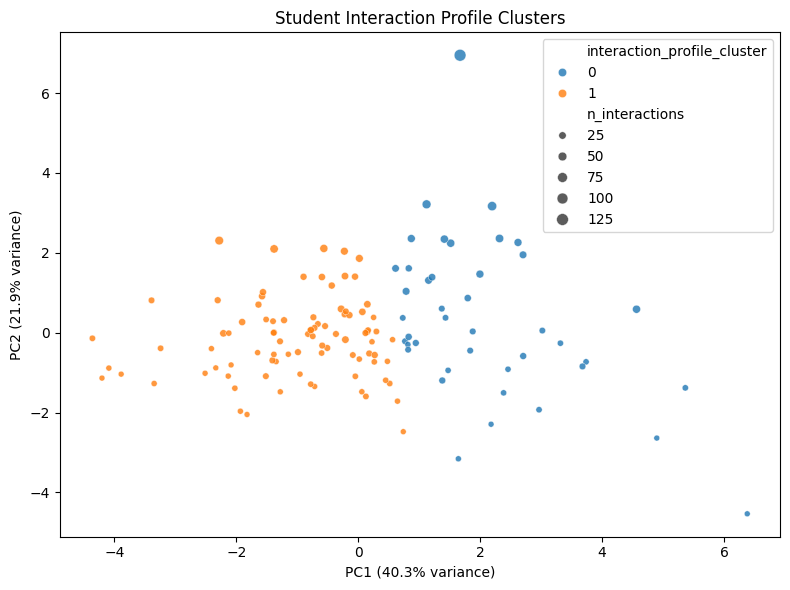

Saved: /content/recipe4u_genai_feedback_outputs/Figure_6_Student_Interaction_Profile_Clusters.png

PCA Explained Variance


,principal_component,explained_variance_ratio,explained_variance_percent
0,PC1,0.4026,40.2631
1,PC2,0.2189,21.8890



Cluster-wise PCA and Interaction Profile Summary


,interaction_profile_cluster,n_students,mean_PC1,sd_PC1,mean_PC2,sd_PC2,mean_n_interactions,mean_rating,mean_edit_rate,mean_user_words,mean_ai_words,mean_ai_flesch,mean_ai_complexity,mean_feedback_accessibility,mean_n_intents
0,0,42,2.1036,1.3551,0.3212,2.0039,21.0714,4.1286,0.2713,117.5347,159.2375,49.2486,0.3420,-0.6776,5.8095
1,1,88,-1.0040,1.1805,-0.1533,0.9888,11.6818,3.9649,0.1723,57.2582,89.5770,61.4433,-0.2348,0.5177,4.0341



Student-level PCA Coordinates and Profile Data


,student_id,interaction_profile_cluster,PC1,PC2,n_interactions,mean_rating,edit_rate,mean_user_words,mean_ai_words,mean_ai_flesch,mean_ai_complexity,mean_feedback_accessibility,n_intents
0,037016a822,1,0.6438,-1.7137,3,4.0000,0.3333,118.6667,177.3333,58.4127,0.0687,0.0606,2
1,03bc4d0231,1,-1.3822,0.0056,13,5.0000,0.0000,19.6923,50.1538,58.5710,-0.3397,0.4769,2
2,09a288d929,1,-0.5076,-0.3822,13,4.0769,0.3846,7.3846,111.2308,59.8756,-0.0579,0.2614,3
3,0b0865942e,1,0.1805,-0.5200,14,4.5000,0.4286,103.1429,136.7143,62.2138,-0.0640,0.3861,5
4,0ca432e0ad,0,1.3700,0.6022,11,2.6364,0.0000,71.9091,102.7273,44.5323,0.4125,-0.9874,5
5,0ebb2f2854,0,0.6121,1.6100,26,3.5385,0.0769,83.1538,88.5000,52.3202,0.0884,-0.2682,8
6,1351dab435,1,-4.0886,-0.8856,3,3.6667,0.0000,12.6667,43.3333,79.7426,-0.6245,1.8358,2
7,13845f9b4a,1,0.5167,-1.2711,7,5.0000,0.7143,69.2857,156.8571,62.4875,0.0218,0.3142,4
8,169854ab97,1,-0.3654,-0.0317,12,3.4167,0.4167,22.2500,48.4167,51.3517,-0.0993,-0.1297,3
9,17b7fc9f24,0,1.7958,0.8662,21,4.1429,0.0952,146.7619,113.0476,48.8526,0.2690,-0.6247,7


Saved: /content/recipe4u_genai_feedback_outputs/Table_14_Student_Level_PCA_Coordinates.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_15_PCA_Cluster_Profile_Summary.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_16_PCA_Explained_Variance.xlsx


In [35]:
# Cell 30 — PCA visualization of student profiles

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

cluster_df["PC1"] = coords[:, 0]
cluster_df["PC2"] = coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="interaction_profile_cluster",
    size="n_interactions",
    alpha=0.8
)
plt.title("Student Interaction Profile Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_6_Student_Interaction_Profile_Clusters.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)




# ---- Copy-pasteable tabular data below the PCA plot ----

# Student-level PCA coordinate table
pca_table = cluster_df[
    [
        "student_id",
        "interaction_profile_cluster",
        "PC1",
        "PC2",
        "n_interactions",
        "mean_rating",
        "edit_rate",
        "mean_user_words",
        "mean_ai_words",
        "mean_ai_flesch",
        "mean_ai_complexity",
        "mean_feedback_accessibility",
        "n_intents"
    ]
].copy()

pca_table = pca_table.round(4)

# Cluster-wise PCA and profile summary
pca_cluster_summary = (
    pca_table
    .groupby("interaction_profile_cluster")
    .agg(
        n_students=("student_id", "count"),
        mean_PC1=("PC1", "mean"),
        sd_PC1=("PC1", "std"),
        mean_PC2=("PC2", "mean"),
        sd_PC2=("PC2", "std"),
        mean_n_interactions=("n_interactions", "mean"),
        mean_rating=("mean_rating", "mean"),
        mean_edit_rate=("edit_rate", "mean"),
        mean_user_words=("mean_user_words", "mean"),
        mean_ai_words=("mean_ai_words", "mean"),
        mean_ai_flesch=("mean_ai_flesch", "mean"),
        mean_ai_complexity=("mean_ai_complexity", "mean"),
        mean_feedback_accessibility=("mean_feedback_accessibility", "mean"),
        mean_n_intents=("n_intents", "mean")
    )
    .reset_index()
    .round(4)
)

# PCA explained variance table
pca_variance_table = pd.DataFrame({
    "principal_component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_percent": pca.explained_variance_ratio_ * 100
}).round(4)

# Save tables
pca_table_path = OUTPUT_DIR / "Table_14_Student_Level_PCA_Coordinates.xlsx"
pca_cluster_summary_path = OUTPUT_DIR / "Table_15_PCA_Cluster_Profile_Summary.xlsx"
pca_variance_path = OUTPUT_DIR / "Table_16_PCA_Explained_Variance.xlsx"

pca_table.to_excel(pca_table_path, index=False)
pca_cluster_summary.to_excel(pca_cluster_summary_path, index=False)
pca_variance_table.to_excel(pca_variance_path, index=False)

# Display below plot
print("\nPCA Explained Variance")
display(pca_variance_table)

print("\nCluster-wise PCA and Interaction Profile Summary")
display(pca_cluster_summary)

print("\nStudent-level PCA Coordinates and Profile Data")
display(pca_table.head(30))

print("Saved:", pca_table_path)
print("Saved:", pca_cluster_summary_path)
print("Saved:", pca_variance_path)

In [32]:
# Cell 31 — Export final analysis dataset

final_data_path = OUTPUT_DIR / "recipe4u_full_metrics_dataset.xlsx"
df_metrics.to_excel(final_data_path, index=False)

print("Saved:", final_data_path)

Saved: /content/recipe4u_genai_feedback_outputs/recipe4u_full_metrics_dataset.xlsx


In [33]:
# Cell 32 — Export all current tables into one Excel workbook

combined_path = OUTPUT_DIR / "All_RECIPE4U_Publication_Tables_Phase1.xlsx"

with pd.ExcelWriter(combined_path, engine="xlsxwriter") as writer:
    dataset_summary.to_excel(writer, sheet_name="T1_Dataset_Summary", index=False)
    rating_dist.to_excel(writer, sheet_name="T2a_Rating_Dist", index=False)
    essay_edit_dist.to_excel(writer, sheet_name="T2b_Edit_Dist", index=False)
    intent_dist.to_excel(writer, sheet_name="T3_Intent_Dist", index=False)
    readability_desc.to_excel(writer, sheet_name="T4_Readability_Desc")
    comparison_table.to_excel(writer, sheet_name="T5_Edit_Comparison", index=False)
    rating_corr_table.to_excel(writer, sheet_name="T6_Rating_Corr", index=False)
    corr_matrix.to_excel(writer, sheet_name="T7_Corr_Matrix")
    intent_summary.to_excel(writer, sheet_name="T8_Intent_Outcomes", index=False)
    logit_table.to_excel(writer, sheet_name="T9_Logit_Edit", index=False)
    rating_reg_table.to_excel(writer, sheet_name="T10_OLS_Rating", index=False)
    student_level.to_excel(writer, sheet_name="T11_Student_Level", index=False)
    cluster_summary.to_excel(writer, sheet_name="T12_Clusters")
    silhouette_table.to_excel(writer, sheet_name="T13_Silhouette", index=False)

print("Saved:", combined_path)

Saved: /content/recipe4u_genai_feedback_outputs/All_RECIPE4U_Publication_Tables_Phase1.xlsx


In [34]:
# Cell 33 — Generate phase-1 statistical summary text

def p_text(p):
    if pd.isna(p):
        return "p = NA"
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}".replace("0.", ".")

summary_lines = []

summary_lines.append("Phase-1 RECIPE4U analysis summary")
summary_lines.append("=" * 50)
summary_lines.append(f"Total interaction rows analyzed: {len(df_metrics)}")
summary_lines.append(f"Unique students: {df_metrics['student_id'].nunique()}")
summary_lines.append(f"Unique intent labels: {df_metrics['intent_final'].nunique()}")
summary_lines.append(f"Mean satisfaction rating: {df_metrics['rating_numeric'].mean():.3f}")
summary_lines.append(f"Essay-edit uptake rate: {df_metrics['essay_edited_binary'].mean():.3f}")
summary_lines.append("")

summary_lines.append("Top significant edited vs non-edited differences after FDR correction:")
sig_comp = comparison_table[comparison_table["p_value_fdr"] < 0.05].copy()
if len(sig_comp) == 0:
    summary_lines.append("No variables were significant after FDR correction.")
else:
    for _, row in sig_comp.iterrows():
        summary_lines.append(
            f"- {row['variable']}: edited mean = {row['edited_mean']:.3f}, "
            f"not-edited mean = {row['not_edited_mean']:.3f}, "
            f"FDR-adjusted {p_text(row['p_value_fdr'])}."
        )

summary_lines.append("")
summary_lines.append("Top correlations with student rating after FDR correction:")
sig_corr = rating_corr_table[rating_corr_table["p_value_fdr"] < 0.05].copy()
if len(sig_corr) == 0:
    summary_lines.append("No correlations were significant after FDR correction.")
else:
    for _, row in sig_corr.iterrows():
        summary_lines.append(
            f"- {row['predictor']}: Spearman rho = {row['spearman_rho']:.3f}, "
            f"FDR-adjusted {p_text(row['p_value_fdr'])}."
        )

summary_text = "\n".join(summary_lines)

summary_path = OUTPUT_DIR / "Phase1_Statistical_Summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved:", summary_path)

Phase-1 RECIPE4U analysis summary
Total interaction rows analyzed: 1913
Unique students: 130
Unique intent labels: 13
Mean satisfaction rating: 4.125
Essay-edit uptake rate: 0.183

Top significant edited vs non-edited differences after FDR correction:
- ai_flesch_reading_ease: edited mean = 52.294, not-edited mean = 56.667, FDR-adjusted p < .001.
- ai_flesch_kincaid_grade: edited mean = 10.572, not-edited mean = 9.612, FDR-adjusted p < .001.
- ai_smog_index: edited mean = 12.781, not-edited mean = 11.594, FDR-adjusted p < .001.
- ai_coleman_liau_index: edited mean = 10.947, not-edited mean = 9.515, FDR-adjusted p < .001.
- ai_automated_readability_index: edited mean = 11.899, not-edited mean = 10.492, FDR-adjusted p < .001.
- ai_dale_chall_readability_score: edited mean = 9.954, not-edited mean = 9.686, FDR-adjusted p < .001.
- ai_difficult_words: edited mean = 34.499, not-edited mean = 21.163, FDR-adjusted p < .001.
- ai_gunning_fog: edited mean = 13.228, not-edited mean = 11.899, FDR

In [41]:
# Cell 34 — Download all saved tables, figures, and outputs as a ZIP file

import shutil
from google.colab import files
from pathlib import Path
import os

# Make sure OUTPUT_DIR exists
OUTPUT_DIR = Path(OUTPUT_DIR)

# Create ZIP filename
zip_filename = "/content/RECIPE4U_Phase1_All_Publication_Outputs"

# Remove old ZIP if already exists
if Path(zip_filename + ".zip").exists():
    os.remove(zip_filename + ".zip")

# Create ZIP archive of the entire output folder
shutil.make_archive(
    base_name=zip_filename,
    format="zip",
    root_dir=OUTPUT_DIR
)

zip_path = zip_filename + ".zip"

print("ZIP file created successfully:")
print(zip_path)

# Show files included in the ZIP
print("\nFiles included:")
for file in sorted(OUTPUT_DIR.glob("*")):
    print("-", file.name)

# Download ZIP to local system
files.download(zip_path)

ZIP file created successfully:
/content/RECIPE4U_Phase1_All_Publication_Outputs.zip

Files included:
- All_RECIPE4U_Publication_Tables_Phase1.xlsx
- Figure_10_Readability_Descriptive_Means_SD.png
- Figure_1_Rating_Distribution.png
- Figure_2_Top_Intent_Labels.png
- Figure_3_Correlation_Heatmap.png
- Figure_4_Feedback_Accessibility_by_Essay_Edit.png
- Figure_5_Response_Length_by_Rating.png
- Figure_6_Student_Interaction_Profile_Clusters.png
- Figure_7_Silhouette_Scores_Student_Clusters.png
- Figure_8_Correlations_With_Satisfaction_Rating.png
- Figure_9_Readability_Descriptive_Means.png
- Phase1_Statistical_Summary.txt
- Table_10_OLS_Regression_Satisfaction_Rating.xlsx
- Table_11_Student_Level_Aggregation.xlsx
- Table_12_Student_Interaction_Profile_Clusters.xlsx
- Table_13_Cluster_Silhouette_Scores.xlsx
- Table_14_Student_Level_PCA_Coordinates.xlsx
- Table_15_PCA_Cluster_Profile_Summary.xlsx
- Table_16_PCA_Explained_Variance.xlsx
- Table_17_Feedback_Accessibility_by_Essay_Edit.xlsx
- Tab

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

What this phase gives you

After these cells, you will already have:

dataset summary table,
rating distribution,
essay-edit uptake distribution,
student intent distribution,
ChatGPT feedback readability metrics,
comparison of edited vs non-edited cases,
correlation with satisfaction,
logistic regression predicting essay-edit uptake,
OLS regression predicting satisfaction rating,
student-level interaction profile clusters,
six publication-quality figures,
one combined Excel workbook of tables.

Next we should add the ChatGPT API-based pedagogical coding layer, where GPT scores each chatgpt_after response for:

clarity

specificity

empathy

self-regulation support

scaffolding

direct-answer tendency

dependency-risk encouragement



That layer will make the paper much stronger than readability-only analysis.

In [42]:
# Cell 35 — Install and initialize OpenAI API

!pip -q install openai


In [43]:
# Cell 35A — Initialize OpenAI API securely

import os
import json
import time
import re
from getpass import getpass
from openai import OpenAI

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

print("OpenAI client initialized successfully.")

Enter your OpenAI API key: ··········
OpenAI client initialized successfully.


In [44]:
#Cell 36 — Define GPT pedagogical coding rubric

# Cell 36 — GPT pedagogical coding rubric for ChatGPT feedback responses

PEDAGOGICAL_CODING_INSTRUCTIONS = """
You are an expert educational researcher coding GenAI feedback in higher education.

You will receive:
1. a student's message,
2. a ChatGPT response to that student,
3. optional context from the previous ChatGPT response,
4. optional intent label from the dataset.

Your task is to evaluate the pedagogical quality of the ChatGPT response.

Return ONLY valid JSON with the following keys:

{
  "clarity": integer 1-5,
  "specificity": integer 1-5,
  "empathy": integer 1-5,
  "self_regulation_support": integer 1-5,
  "scaffolding": integer 1-5,
  "direct_answer_tendency": integer 1-5,
  "dependency_risk_encouragement": integer 1-5,
  "actionability": integer 1-5,
  "feedback_depth": integer 1-5,
  "non_judgmental_tone": integer 1-5,
  "brief_rationale": string, maximum 80 words
}

Scoring guide:
1 = very low
2 = low
3 = moderate
4 = high
5 = very high

Dimension definitions:

clarity:
How understandable, well-organized, and accessible the response is.

specificity:
How much the response addresses the student's actual request or text rather than giving generic advice.

empathy:
How supportive, respectful, encouraging, and emotionally sensitive the response is.

self_regulation_support:
Whether the response encourages planning, monitoring, reflection, revision, strategy selection, or independent checking.

scaffolding:
Whether the response guides the student step by step without simply doing all the cognitive work.

direct_answer_tendency:
Whether the response directly gives the answer, complete solution, rewrite, or finished product.

dependency_risk_encouragement:
Whether the response may encourage over-reliance, copy-paste use, or cognitive outsourcing.

actionability:
Whether the response provides concrete next steps that the student can act upon.

feedback_depth:
Whether the response provides meaningful explanation, reasoning, diagnosis, or improvement guidance.

non_judgmental_tone:
Whether the response avoids blaming, shaming, stereotyping, or deficit framing.

Important rules:
- Do not automatically reward long responses.
- A response can be clear but still have high dependency risk.
- A response can be supportive but not specific.
- Penalize responses that simply complete the task without encouraging student thinking.
- Reward responses that help the student understand, revise, monitor, or improve independently.
- If the response is empty, irrelevant, or impossible to judge, use null for numeric fields and explain briefly.
- Return only JSON. Do not include markdown.
"""

In [45]:
# Cell 37 — Helper functions for JSON extraction and API call

# Cell 37 — Helper functions for GPT coding

def extract_json_safely(text):
    """
    Extract valid JSON from model output.
    """
    if text is None:
        raise ValueError("Empty model output")

    text = text.strip()

    try:
        return json.loads(text)
    except Exception:
        pass

    # Try to extract first JSON object
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        return json.loads(match.group(0))

    raise ValueError("No valid JSON object found.")


def code_feedback_with_gpt(
    user_message,
    chatgpt_response,
    chatgpt_before="",
    intent_final="",
    model="gpt-5.4-mini",
    max_retries=3,
    sleep_between_retries=2
):
    """
    Code one ChatGPT response using OpenAI Responses API.
    """

    user_message = "" if pd.isna(user_message) else str(user_message)
    chatgpt_response = "" if pd.isna(chatgpt_response) else str(chatgpt_response)
    chatgpt_before = "" if pd.isna(chatgpt_before) else str(chatgpt_before)
    intent_final = "" if pd.isna(intent_final) else str(intent_final)

    if len(chatgpt_response.strip()) < 20:
        return {
            "clarity": None,
            "specificity": None,
            "empathy": None,
            "self_regulation_support": None,
            "scaffolding": None,
            "direct_answer_tendency": None,
            "dependency_risk_encouragement": None,
            "actionability": None,
            "feedback_depth": None,
            "non_judgmental_tone": None,
            "brief_rationale": "Response too short or empty for reliable coding."
        }

    coding_input = f"""
DATASET INTENT LABEL:
{intent_final}

PREVIOUS CHATGPT CONTEXT:
{chatgpt_before[:1500]}

STUDENT MESSAGE:
{user_message[:2000]}

CHATGPT RESPONSE TO BE CODED:
{chatgpt_response[:4000]}
"""

    for attempt in range(max_retries):
        try:
            response = client.responses.create(
                model=model,
                instructions=PEDAGOGICAL_CODING_INSTRUCTIONS,
                input=coding_input
            )

            parsed = extract_json_safely(response.output_text)

            expected_keys = [
                "clarity",
                "specificity",
                "empathy",
                "self_regulation_support",
                "scaffolding",
                "direct_answer_tendency",
                "dependency_risk_encouragement",
                "actionability",
                "feedback_depth",
                "non_judgmental_tone",
                "brief_rationale"
            ]

            for key in expected_keys:
                if key not in parsed:
                    parsed[key] = None

            return parsed

        except Exception as e:
            print(f"Attempt {attempt + 1} failed:", e)
            time.sleep(sleep_between_retries * (attempt + 1))

    return {
        "clarity": None,
        "specificity": None,
        "empathy": None,
        "self_regulation_support": None,
        "scaffolding": None,
        "direct_answer_tendency": None,
        "dependency_risk_encouragement": None,
        "actionability": None,
        "feedback_depth": None,
        "non_judgmental_tone": None,
        "brief_rationale": "GPT coding failed after retries."
    }

In [46]:
# Cell 38 — Test GPT coding on 3 sample rows

# Run this before full coding.


# Cell 38 — Test GPT coding on a small sample

test_sample = df_metrics[
    df_metrics["chatgpt_after"].fillna("").str.len() > 20
].sample(
    n=min(3, len(df_metrics)),
    random_state=RANDOM_STATE
)

test_coded_rows = []

for _, row in test_sample.iterrows():
    coded = code_feedback_with_gpt(
        user_message=row.get("user", ""),
        chatgpt_response=row.get("chatgpt_after", ""),
        chatgpt_before=row.get("chatgpt_before", ""),
        intent_final=row.get("intent_final", ""),
        model="gpt-5.4-mini"
    )

    coded["sample_id"] = row.get("sample_id", None)
    coded["student_id"] = row.get("student_id", None)
    coded["intent_final"] = row.get("intent_final", None)
    coded["rating_numeric"] = row.get("rating_numeric", None)
    coded["essay_edited_binary"] = row.get("essay_edited_binary", None)

    test_coded_rows.append(coded)

test_coded_df = pd.DataFrame(test_coded_rows)

print("GPT coding test completed.")
display(test_coded_df)

GPT coding test completed.


,clarity,specificity,empathy,self_regulation_support,scaffolding,direct_answer_tendency,dependency_risk_encouragement,actionability,feedback_depth,non_judgmental_tone,brief_rationale,sample_id,student_id,intent_final,rating_numeric,essay_edited_binary
0,5,3,4,3,3,2,2,3,3,5,Clear and supportive explanation of what a dis...,5574d85dc3-SW-6-1-02,5574d85dc3,Answer,5,0
1,4,4,4,3,3,4,3,4,3,5,"The response is clear, supportive, and directl...",b8b7332263-AW-2-1-04,b8b7332263,Answer,4,1
2,5,2,5,2,1,1,1,2,1,5,"Polite and clear acknowledgement, but it adds ...",a6ff7e0d07-IRW-3-1-03,a6ff7e0d07,ACK,5,0


In [47]:
# Cell 39 — Configure full or partial GPT coding

# For first run, keep RUN_FULL_GPT_CODING = False. It will code only 25 rows.

# Cell 39 — Configure GPT coding run

RUN_FULL_GPT_CODING = False   # Change to True only after test looks good
N_SAMPLE_TO_CODE = 25         # Used only if RUN_FULL_GPT_CODING = False

GPT_CODING_MODEL = "gpt-5.4-mini"

coding_input_df = df_metrics[
    df_metrics["chatgpt_after"].fillna("").str.len() > 20
].copy()

if RUN_FULL_GPT_CODING:
    coding_run_df = coding_input_df.copy()
else:
    coding_run_df = coding_input_df.sample(
        n=min(N_SAMPLE_TO_CODE, len(coding_input_df)),
        random_state=RANDOM_STATE
    ).copy()

print("Rows available for GPT coding:", len(coding_input_df))
print("Rows selected for this run:", len(coding_run_df))
print("Model:", GPT_CODING_MODEL)

Rows available for GPT coding: 1880
Rows selected for this run: 25
Model: gpt-5.4-mini


In [48]:
# Cell 40 — Run GPT coding with resume-safe saving

# This saves after every 10 rows. If interrupted, you can restart and avoid losing results.

# Cell 40 — Run GPT-based pedagogical coding

gpt_coding_output_path = OUTPUT_DIR / "GPT_Pedagogical_Coding_RECIPE4U.xlsx"
gpt_coding_checkpoint_path = OUTPUT_DIR / "GPT_Pedagogical_Coding_RECIPE4U_checkpoint.csv"

# Load existing checkpoint if available
if gpt_coding_checkpoint_path.exists():
    existing_coded = pd.read_csv(gpt_coding_checkpoint_path)
    already_done_ids = set(existing_coded["sample_id"].astype(str))
    coded_rows = existing_coded.to_dict("records")
    print("Loaded checkpoint:", gpt_coding_checkpoint_path)
    print("Already coded rows:", len(already_done_ids))
else:
    already_done_ids = set()
    coded_rows = []

for counter, (_, row) in enumerate(tqdm(coding_run_df.iterrows(), total=len(coding_run_df), desc="GPT coding feedback"), start=1):

    sample_id_str = str(row.get("sample_id", ""))

    if sample_id_str in already_done_ids:
        continue

    coded = code_feedback_with_gpt(
        user_message=row.get("user", ""),
        chatgpt_response=row.get("chatgpt_after", ""),
        chatgpt_before=row.get("chatgpt_before", ""),
        intent_final=row.get("intent_final", ""),
        model=GPT_CODING_MODEL
    )

    coded["sample_id"] = row.get("sample_id", None)
    coded["course"] = row.get("course", None)
    coded["student_id"] = row.get("student_id", None)
    coded["week"] = row.get("week", None)
    coded["session"] = row.get("session", None)
    coded["idx"] = row.get("idx", None)
    coded["intent_final"] = row.get("intent_final", None)
    coded["rating_numeric"] = row.get("rating_numeric", None)
    coded["essay_edited_binary"] = row.get("essay_edited_binary", None)

    coded_rows.append(coded)
    already_done_ids.add(sample_id_str)

    # Save checkpoint every 10 newly processed rows
    if counter % 10 == 0:
        pd.DataFrame(coded_rows).to_csv(gpt_coding_checkpoint_path, index=False)
        print(f"Checkpoint saved after {counter} loop iterations.")

# Final save
gpt_coded_df = pd.DataFrame(coded_rows)
gpt_coded_df.to_csv(gpt_coding_checkpoint_path, index=False)
gpt_coded_df.to_excel(gpt_coding_output_path, index=False)

print("GPT coding completed.")
print("Rows coded:", len(gpt_coded_df))
print("Saved:", gpt_coding_checkpoint_path)
print("Saved:", gpt_coding_output_path)

display(gpt_coded_df.head())

GPT coding feedback:   0%|          | 0/25 [00:00<?, ?it/s]

Checkpoint saved after 10 loop iterations.
Checkpoint saved after 20 loop iterations.
GPT coding completed.
Rows coded: 25
Saved: /content/recipe4u_genai_feedback_outputs/GPT_Pedagogical_Coding_RECIPE4U_checkpoint.csv
Saved: /content/recipe4u_genai_feedback_outputs/GPT_Pedagogical_Coding_RECIPE4U.xlsx


,clarity,specificity,empathy,self_regulation_support,scaffolding,direct_answer_tendency,dependency_risk_encouragement,actionability,feedback_depth,non_judgmental_tone,brief_rationale,sample_id,course,student_id,week,session,idx,intent_final,rating_numeric,essay_edited_binary
0,4,3,4,3,3,3,2,3,3,5,"The response is clear, supportive, and appropr...",5574d85dc3-SW-6-1-02,SW,5574d85dc3,6,1,2,Answer,5,0
1,4,4,4,3,3,4,3,3,3,5,"Supportive and clear, with a specific revision...",b8b7332263-AW-2-1-04,AW,b8b7332263,2,1,4,Answer,4,1
2,5,2,4,2,1,1,1,2,1,5,Polite and clear acknowledgement with an open ...,a6ff7e0d07-IRW-3-1-03,IRW,a6ff7e0d07,3,1,3,ACK,5,0
3,5,2,5,2,1,1,2,1,1,5,Warm and clear acknowledgment of the student’s...,80981202b8-AW-3-1-04,AW,80981202b8,3,1,4,ACK,5,0
4,5,5,3,1,1,5,4,1,1,5,The response is clear and directly addresses t...,43bca7f66e-SW-2-1-01,SW,43bca7f66e,2,1,1,R Language Use,4,0


In [49]:
# Cell 41 — Clean GPT coding results and create pedagogical indices

# Cell 41 — Clean GPT coding results and create pedagogical indices

gpt_score_cols = [
    "clarity",
    "specificity",
    "empathy",
    "self_regulation_support",
    "scaffolding",
    "direct_answer_tendency",
    "dependency_risk_encouragement",
    "actionability",
    "feedback_depth",
    "non_judgmental_tone"
]

gpt_coded_clean = gpt_coded_df.copy()

for col in gpt_score_cols:
    gpt_coded_clean[col] = pd.to_numeric(gpt_coded_clean[col], errors="coerce")

# Positive pedagogical quality dimensions
positive_quality_cols = [
    "clarity",
    "specificity",
    "empathy",
    "self_regulation_support",
    "scaffolding",
    "actionability",
    "feedback_depth",
    "non_judgmental_tone"
]

# Risk dimensions
risk_cols = [
    "direct_answer_tendency",
    "dependency_risk_encouragement"
]

gpt_coded_clean["gpt_positive_feedback_quality_index"] = (
    gpt_coded_clean[positive_quality_cols].mean(axis=1)
)

gpt_coded_clean["gpt_dependency_risk_index"] = (
    gpt_coded_clean[risk_cols].mean(axis=1)
)

# Final utility index:
# high positive quality and low dependency risk
gpt_coded_clean["gpt_pedagogical_utility_index"] = (
    gpt_coded_clean["gpt_positive_feedback_quality_index"]
    - gpt_coded_clean["gpt_dependency_risk_index"]
)

# Self-regulated scaffolding index
gpt_coded_clean["gpt_srl_scaffolding_index"] = (
    gpt_coded_clean[["self_regulation_support", "scaffolding", "actionability"]].mean(axis=1)
)

gpt_indices_path = OUTPUT_DIR / "GPT_Pedagogical_Coding_With_Indices_RECIPE4U.xlsx"
gpt_coded_clean.to_excel(gpt_indices_path, index=False)

print("Saved:", gpt_indices_path)
display(gpt_coded_clean.head())

Saved: /content/recipe4u_genai_feedback_outputs/GPT_Pedagogical_Coding_With_Indices_RECIPE4U.xlsx


,clarity,specificity,empathy,self_regulation_support,scaffolding,direct_answer_tendency,dependency_risk_encouragement,actionability,feedback_depth,non_judgmental_tone,...,week,session,idx,intent_final,rating_numeric,essay_edited_binary,gpt_positive_feedback_quality_index,gpt_dependency_risk_index,gpt_pedagogical_utility_index,gpt_srl_scaffolding_index
0,4,3,4,3,3,3,2,3,3,5,...,6,1,2,Answer,5,0,3.500,2.5,1.000,3.000000
1,4,4,4,3,3,4,3,3,3,5,...,2,1,4,Answer,4,1,3.625,3.5,0.125,3.000000
2,5,2,4,2,1,1,1,2,1,5,...,3,1,3,ACK,5,0,2.750,1.0,1.750,1.666667
3,5,2,5,2,1,1,2,1,1,5,...,3,1,4,ACK,5,0,2.750,1.5,1.250,1.333333
4,5,5,3,1,1,5,4,1,1,5,...,2,1,1,R Language Use,4,0,2.750,4.5,-1.750,1.000000


In [50]:
# Cell 42 — Merge GPT coding with full RECIPE4U metrics dataset

# Cell 42 — Merge GPT-coded scores with full metrics dataset

# Prevent duplicate columns during merge
gpt_merge_cols = [
    "sample_id"
] + gpt_score_cols + [
    "gpt_positive_feedback_quality_index",
    "gpt_dependency_risk_index",
    "gpt_pedagogical_utility_index",
    "gpt_srl_scaffolding_index",
    "brief_rationale"
]

df_gpt_metrics = df_metrics.merge(
    gpt_coded_clean[gpt_merge_cols],
    on="sample_id",
    how="left"
)

merged_path = OUTPUT_DIR / "RECIPE4U_Metrics_With_GPT_Pedagogical_Coding.xlsx"
df_gpt_metrics.to_excel(merged_path, index=False)

print("Merged dataset shape:", df_gpt_metrics.shape)
print("Saved:", merged_path)

df_gpt_metrics[
    [
        "sample_id",
        "rating_numeric",
        "essay_edited_binary",
        "intent_final",
        "gpt_positive_feedback_quality_index",
        "gpt_dependency_risk_index",
        "gpt_pedagogical_utility_index",
        "gpt_srl_scaffolding_index"
    ]
].dropna(how="all").head()

Merged dataset shape: (1913, 76)
Saved: /content/recipe4u_genai_feedback_outputs/RECIPE4U_Metrics_With_GPT_Pedagogical_Coding.xlsx


,sample_id,rating_numeric,essay_edited_binary,intent_final,gpt_positive_feedback_quality_index,gpt_dependency_risk_index,gpt_pedagogical_utility_index,gpt_srl_scaffolding_index
0,9f45c512db-SW-1-1-01,4,0,Answer,NaN,NaN,NaN,NaN
1,9f45c512db-SW-1-1-02,5,0,Answer,NaN,NaN,NaN,NaN
2,9f45c512db-SW-1-1-03,4,0,R Language Use,NaN,NaN,NaN,NaN
3,9f45c512db-SW-1-1-04,2,0,R Language Use,NaN,NaN,NaN,NaN
4,9f45c512db-SW-1-1-05,2,0,Negotiation,NaN,NaN,NaN,NaN


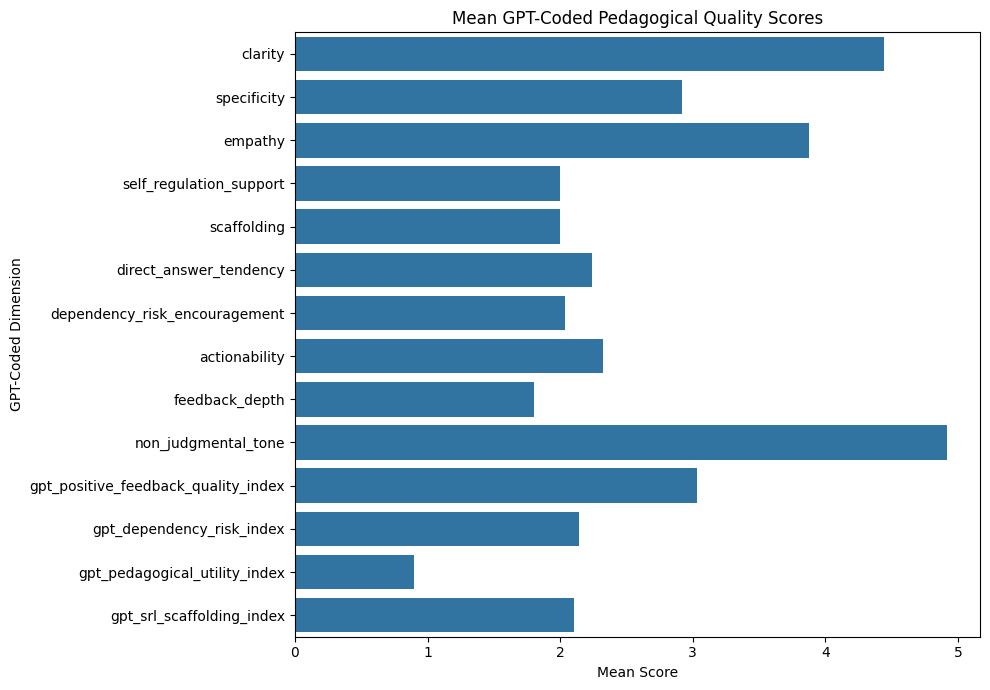

Saved: /content/recipe4u_genai_feedback_outputs/Figure_11_GPT_Pedagogical_Score_Means.png

Descriptive Statistics for GPT-Coded Pedagogical Scores


,metric,count,mean,std,min,25%,50%,75%,max,missing
0,clarity,25.0,4.440,0.712,2.000,4.000,5.000,5.0,5.000,1888
1,specificity,25.0,2.920,1.441,1.000,2.000,3.000,4.0,5.000,1888
2,empathy,25.0,3.880,0.526,3.000,4.000,4.000,4.0,5.000,1888
3,self_regulation_support,25.0,2.000,0.645,1.000,2.000,2.000,2.0,3.000,1888
4,scaffolding,25.0,2.000,1.041,1.000,1.000,2.000,3.0,4.000,1888
5,direct_answer_tendency,25.0,2.240,1.535,1.000,1.000,1.000,4.0,5.000,1888
6,dependency_risk_encouragement,25.0,2.040,0.935,1.000,1.000,2.000,2.0,4.000,1888
7,actionability,25.0,2.320,1.069,1.000,1.000,2.000,3.0,4.000,1888
8,feedback_depth,25.0,1.800,1.000,1.000,1.000,1.000,2.0,4.000,1888
9,non_judgmental_tone,25.0,4.920,0.277,4.000,5.000,5.000,5.0,5.000,1888


Saved: /content/recipe4u_genai_feedback_outputs/Table_18_GPT_Pedagogical_Score_Descriptives.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_18b_GPT_Pedagogical_Score_Descriptives_Copy_Paste.xlsx


In [51]:
# Cell 43 — Descriptive statistics for GPT pedagogical scores

# Cell 43 — Descriptive statistics for GPT pedagogical scores

gpt_analysis_cols = gpt_score_cols + [
    "gpt_positive_feedback_quality_index",
    "gpt_dependency_risk_index",
    "gpt_pedagogical_utility_index",
    "gpt_srl_scaffolding_index"
]

gpt_desc = (
    df_gpt_metrics[gpt_analysis_cols]
    .describe()
    .T
)

gpt_desc["missing"] = df_gpt_metrics[gpt_analysis_cols].isna().sum()
gpt_desc = gpt_desc.round(3)

# ---- Plot first ----

gpt_desc_plot = gpt_desc.reset_index().rename(columns={"index": "metric"})

plt.figure(figsize=(10, 7))
sns.barplot(
    data=gpt_desc_plot,
    y="metric",
    x="mean"
)
plt.title("Mean GPT-Coded Pedagogical Quality Scores")
plt.xlabel("Mean Score")
plt.ylabel("GPT-Coded Dimension")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_11_GPT_Pedagogical_Score_Means.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print tabular values ----

gpt_desc_path = OUTPUT_DIR / "Table_18_GPT_Pedagogical_Score_Descriptives.xlsx"
gpt_desc.to_excel(gpt_desc_path)

gpt_desc_copy = gpt_desc.reset_index().rename(columns={"index": "metric"})
gpt_desc_copy_path = OUTPUT_DIR / "Table_18b_GPT_Pedagogical_Score_Descriptives_Copy_Paste.xlsx"
gpt_desc_copy.to_excel(gpt_desc_copy_path, index=False)

print("\nDescriptive Statistics for GPT-Coded Pedagogical Scores")
display(gpt_desc_copy)

print("Saved:", gpt_desc_path)
print("Saved:", gpt_desc_copy_path)

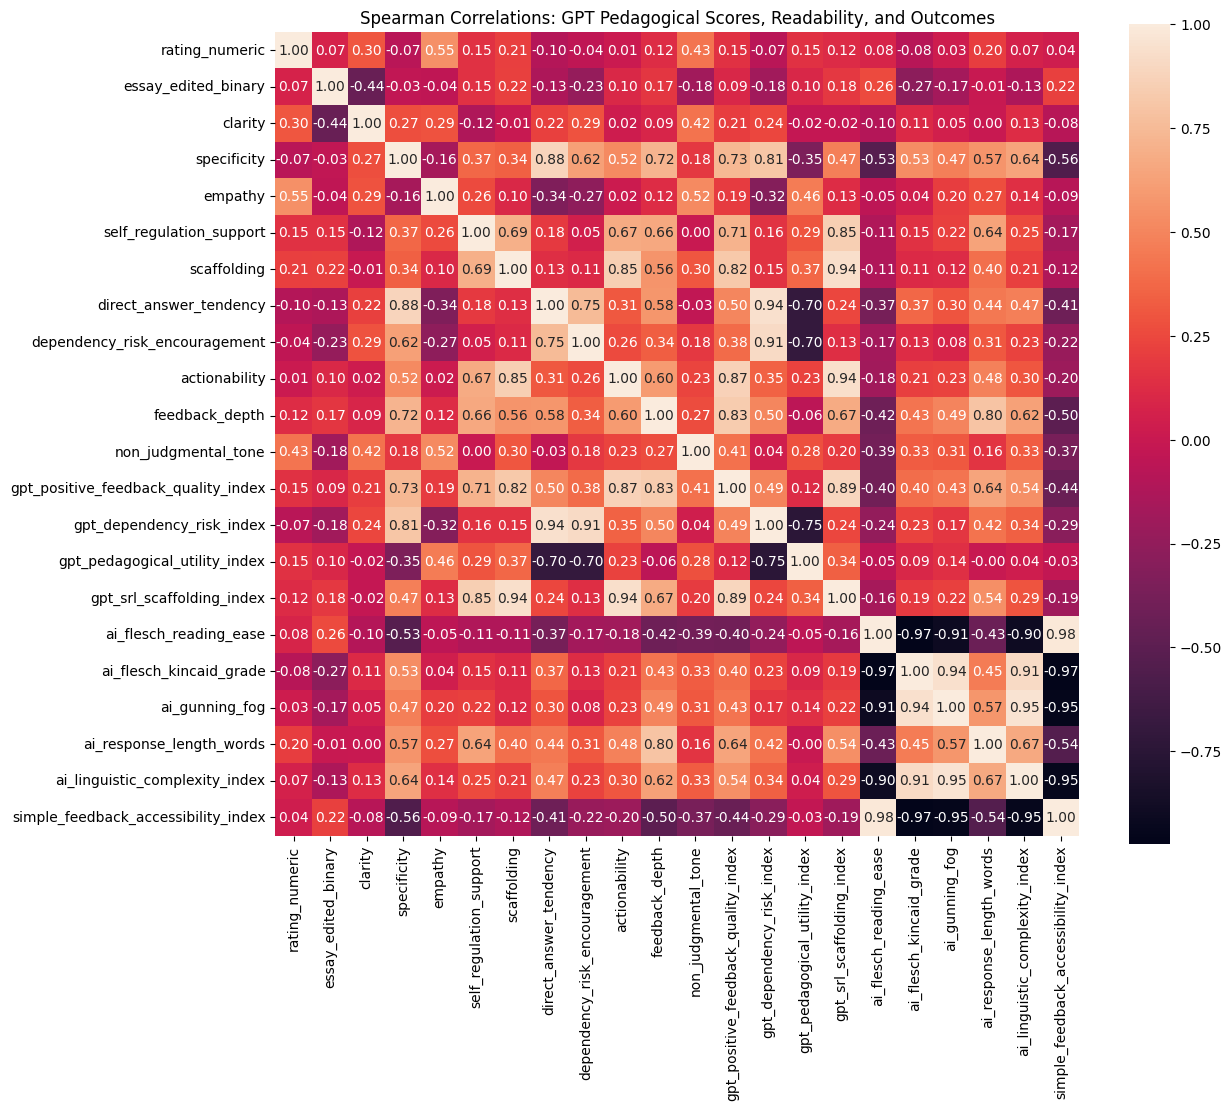

Saved: /content/recipe4u_genai_feedback_outputs/Figure_12_GPT_Scores_Correlation_Heatmap.png

GPT Score Correlation Matrix


,rating_numeric,essay_edited_binary,clarity,specificity,empathy,self_regulation_support,scaffolding,direct_answer_tendency,dependency_risk_encouragement,actionability,...,gpt_positive_feedback_quality_index,gpt_dependency_risk_index,gpt_pedagogical_utility_index,gpt_srl_scaffolding_index,ai_flesch_reading_ease,ai_flesch_kincaid_grade,ai_gunning_fog,ai_response_length_words,ai_linguistic_complexity_index,simple_feedback_accessibility_index
rating_numeric,1.000,0.070,0.302,-0.074,0.548,0.146,0.212,-0.100,-0.040,0.010,...,0.148,-0.075,0.146,0.116,0.081,-0.082,0.026,0.202,0.066,0.036
essay_edited_binary,0.070,1.000,-0.442,-0.033,-0.041,0.148,0.221,-0.127,-0.234,0.101,...,0.092,-0.179,0.098,0.177,0.260,-0.273,-0.169,-0.006,-0.130,0.221
clarity,0.302,-0.442,1.000,0.273,0.286,-0.120,-0.006,0.216,0.287,0.022,...,0.206,0.241,-0.024,-0.019,-0.100,0.110,0.047,0.000,0.126,-0.079
specificity,-0.074,-0.033,0.273,1.000,-0.160,0.370,0.338,0.883,0.616,0.516,...,0.731,0.805,-0.347,0.469,-0.529,0.533,0.473,0.567,0.639,-0.560
empathy,0.548,-0.041,0.286,-0.160,1.000,0.256,0.105,-0.340,-0.270,0.016,...,0.192,-0.316,0.460,0.127,-0.052,0.040,0.201,0.271,0.139,-0.086
self_regulation_support,0.146,0.148,-0.120,0.370,0.256,1.000,0.694,0.185,0.048,0.672,...,0.713,0.157,0.295,0.846,-0.114,0.149,0.219,0.636,0.254,-0.167
scaffolding,0.212,0.221,-0.006,0.338,0.105,0.694,1.000,0.132,0.107,0.853,...,0.818,0.155,0.372,0.935,-0.113,0.107,0.118,0.404,0.211,-0.123
direct_answer_tendency,-0.100,-0.127,0.216,0.883,-0.340,0.185,0.132,1.000,0.748,0.312,...,0.503,0.940,-0.700,0.242,-0.374,0.374,0.299,0.443,0.469,-0.410
dependency_risk_encouragement,-0.040,-0.234,0.287,0.616,-0.270,0.048,0.107,0.748,1.000,0.257,...,0.384,0.908,-0.696,0.132,-0.172,0.128,0.082,0.311,0.227,-0.219
actionability,0.010,0.101,0.022,0.516,0.016,0.672,0.853,0.312,0.257,1.000,...,0.868,0.346,0.229,0.936,-0.181,0.214,0.227,0.481,0.304,-0.205



GPT Score Correlation Matrix in Long Format


,variable_1,variable_2,spearman_correlation
0,simple_feedback_accessibility_index,ai_flesch_reading_ease,0.977
1,simple_feedback_accessibility_index,ai_flesch_kincaid_grade,-0.972
2,ai_flesch_kincaid_grade,ai_flesch_reading_ease,-0.972
3,ai_linguistic_complexity_index,ai_gunning_fog,0.955
4,simple_feedback_accessibility_index,ai_gunning_fog,-0.955
5,simple_feedback_accessibility_index,ai_linguistic_complexity_index,-0.948
6,ai_gunning_fog,ai_flesch_kincaid_grade,0.941
7,gpt_dependency_risk_index,direct_answer_tendency,0.940
8,gpt_srl_scaffolding_index,actionability,0.936
9,gpt_srl_scaffolding_index,scaffolding,0.935


Saved: /content/recipe4u_genai_feedback_outputs/Table_19_GPT_Scores_Correlation_Matrix.xlsx
Saved: /content/recipe4u_genai_feedback_outputs/Table_19b_GPT_Scores_Correlation_Long_Format.xlsx


In [52]:
# Cell 44 — Correlation between GPT scores, satisfaction, and essay-edit uptake

# Cell 44 — Correlation between GPT-coded scores and outcomes

gpt_corr_vars = [
    "rating_numeric",
    "essay_edited_binary"
] + gpt_analysis_cols + [
    "ai_flesch_reading_ease",
    "ai_flesch_kincaid_grade",
    "ai_gunning_fog",
    "ai_response_length_words",
    "ai_linguistic_complexity_index",
    "simple_feedback_accessibility_index"
]

gpt_corr_data = df_gpt_metrics[gpt_corr_vars].dropna(subset=["gpt_pedagogical_utility_index"])

gpt_corr_matrix = gpt_corr_data[gpt_corr_vars].corr(method="spearman").round(3)

# ---- Plot first ----

plt.figure(figsize=(13, 11))
sns.heatmap(
    gpt_corr_matrix,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=True
)
plt.title("Spearman Correlations: GPT Pedagogical Scores, Readability, and Outcomes")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_12_GPT_Scores_Correlation_Heatmap.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print tabular values ----

gpt_corr_path = OUTPUT_DIR / "Table_19_GPT_Scores_Correlation_Matrix.xlsx"
gpt_corr_matrix.to_excel(gpt_corr_path)

gpt_corr_long = (
    gpt_corr_matrix
    .reset_index()
    .melt(
        id_vars="index",
        var_name="variable_2",
        value_name="spearman_correlation"
    )
    .rename(columns={"index": "variable_1"})
)

gpt_corr_long["pair_key"] = gpt_corr_long.apply(
    lambda row: " | ".join(sorted([row["variable_1"], row["variable_2"]])),
    axis=1
)

gpt_corr_long_unique = (
    gpt_corr_long[gpt_corr_long["variable_1"] != gpt_corr_long["variable_2"]]
    .drop_duplicates(subset="pair_key")
    .drop(columns="pair_key")
    .sort_values("spearman_correlation", key=lambda x: x.abs(), ascending=False)
    .reset_index(drop=True)
)

gpt_corr_long_path = OUTPUT_DIR / "Table_19b_GPT_Scores_Correlation_Long_Format.xlsx"
gpt_corr_long_unique.to_excel(gpt_corr_long_path, index=False)

print("\nGPT Score Correlation Matrix")
display(gpt_corr_matrix)

print("\nGPT Score Correlation Matrix in Long Format")
display(gpt_corr_long_unique.head(50))

print("Saved:", gpt_corr_path)
print("Saved:", gpt_corr_long_path)

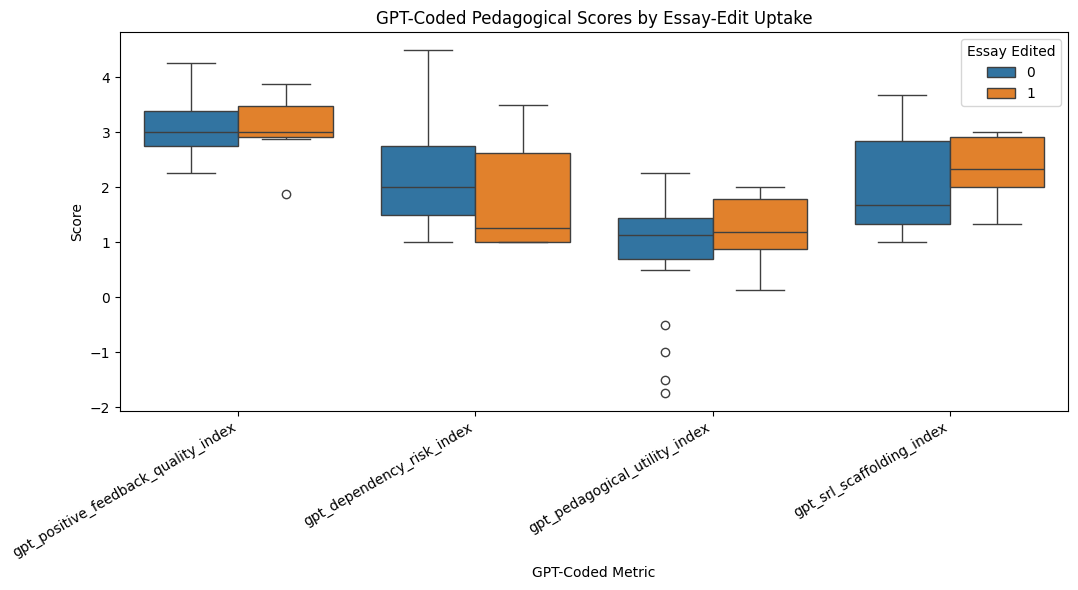

Saved: /content/recipe4u_genai_feedback_outputs/Figure_13_GPT_Scores_by_Essay_Edit.png

GPT-Coded Pedagogical Scores: Edited vs Not Edited


,variable,edited_n,edited_mean,edited_sd,not_edited_n,not_edited_mean,not_edited_sd,mann_whitney_u,p_value,p_value_fdr
0,clarity,6,3.8333,0.9832,19,4.6316,0.4956,27.0,0.0330,0.4625
1,specificity,6,2.8333,1.4720,19,2.9474,1.4710,54.5,0.8957,0.8957
2,empathy,6,3.8333,0.4082,19,3.8947,0.5671,54.5,0.8715,0.8957
3,self_regulation_support,6,2.1667,0.4082,19,1.9474,0.7050,67.0,0.4907,0.7890
4,scaffolding,6,2.3333,0.8165,19,1.8947,1.1002,73.0,0.2947,0.7890
5,direct_answer_tendency,6,2.0000,1.5492,19,2.3158,1.5653,48.0,0.5581,0.7890
6,dependency_risk_encouragement,6,1.6667,0.8165,19,2.1579,0.9582,40.5,0.2657,0.7890
7,actionability,6,2.5000,1.0488,19,2.2632,1.0976,64.5,0.6445,0.7890
8,feedback_depth,6,2.0000,0.8944,19,1.7368,1.0457,69.0,0.4253,0.7890
9,non_judgmental_tone,6,4.8333,0.4082,19,4.9474,0.2294,50.5,0.4169,0.7890


Saved: /content/recipe4u_genai_feedback_outputs/Table_20_GPT_Scores_Edited_vs_Not_Edited.xlsx


In [53]:
# Cell 45 — Edited vs non-edited comparison for GPT pedagogical scores

# Cell 45 — GPT score comparison by essay-edit uptake

gpt_edit_compare_rows = []

for var in gpt_analysis_cols:
    edited = df_gpt_metrics.loc[df_gpt_metrics["essay_edited_binary"] == 1, var].dropna()
    not_edited = df_gpt_metrics.loc[df_gpt_metrics["essay_edited_binary"] == 0, var].dropna()

    if len(edited) > 2 and len(not_edited) > 2:
        u_stat, p_val = mannwhitneyu(edited, not_edited, alternative="two-sided")

        gpt_edit_compare_rows.append({
            "variable": var,
            "edited_n": len(edited),
            "edited_mean": edited.mean(),
            "edited_sd": edited.std(),
            "not_edited_n": len(not_edited),
            "not_edited_mean": not_edited.mean(),
            "not_edited_sd": not_edited.std(),
            "mann_whitney_u": u_stat,
            "p_value": p_val
        })

gpt_edit_compare_table = pd.DataFrame(gpt_edit_compare_rows)

if len(gpt_edit_compare_table) > 0:
    gpt_edit_compare_table["p_value_fdr"] = multipletests(
        gpt_edit_compare_table["p_value"],
        method="fdr_bh"
    )[1]

gpt_edit_compare_table = gpt_edit_compare_table.round(4)

# ---- Plot first ----

plot_vars = [
    "gpt_positive_feedback_quality_index",
    "gpt_dependency_risk_index",
    "gpt_pedagogical_utility_index",
    "gpt_srl_scaffolding_index"
]

plot_data = df_gpt_metrics.melt(
    id_vars="essay_edited_binary",
    value_vars=plot_vars,
    var_name="gpt_metric",
    value_name="score"
).dropna()

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=plot_data,
    x="gpt_metric",
    y="score",
    hue="essay_edited_binary"
)
plt.title("GPT-Coded Pedagogical Scores by Essay-Edit Uptake")
plt.xlabel("GPT-Coded Metric")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Essay Edited")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_13_GPT_Scores_by_Essay_Edit.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print tabular values ----

gpt_edit_compare_path = OUTPUT_DIR / "Table_20_GPT_Scores_Edited_vs_Not_Edited.xlsx"
gpt_edit_compare_table.to_excel(gpt_edit_compare_path, index=False)

print("\nGPT-Coded Pedagogical Scores: Edited vs Not Edited")
display(gpt_edit_compare_table)

print("Saved:", gpt_edit_compare_path)

In [54]:
# Cell 46 — Regression: GPT-coded predictors of satisfaction rating

# Cell 46 — Regression model predicting student satisfaction rating using GPT-coded scores

gpt_rating_model_df = df_gpt_metrics[[
    "rating_numeric",
    "essay_edited_binary",
    "intent_final",
    "ai_flesch_reading_ease",
    "ai_response_length_words",
    "user_prompt_length_words",
    "gpt_positive_feedback_quality_index",
    "gpt_dependency_risk_index",
    "gpt_pedagogical_utility_index",
    "gpt_srl_scaffolding_index"
]].dropna()

gpt_rating_model_df["log_ai_words"] = np.log1p(gpt_rating_model_df["ai_response_length_words"])
gpt_rating_model_df["log_user_words"] = np.log1p(gpt_rating_model_df["user_prompt_length_words"])

top_intents_gpt_rating = gpt_rating_model_df["intent_final"].value_counts().head(10).index
gpt_rating_model_df["intent_model"] = np.where(
    gpt_rating_model_df["intent_final"].isin(top_intents_gpt_rating),
    gpt_rating_model_df["intent_final"],
    "Other"
)

gpt_rating_formula = """
rating_numeric ~
gpt_positive_feedback_quality_index +
gpt_dependency_risk_index +
gpt_srl_scaffolding_index +
ai_flesch_reading_ease +
log_ai_words +
log_user_words +
essay_edited_binary +
C(intent_model)
"""

gpt_rating_model = smf.ols(
    gpt_rating_formula,
    data=gpt_rating_model_df
).fit(cov_type="HC3")

print(gpt_rating_model.summary())

                            OLS Regression Results                            
Dep. Variable:         rating_numeric   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     3.051
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0411
Time:                        13:16:50   Log-Likelihood:                -24.651
No. Observations:                  25   AIC:                             79.30
Df Residuals:                      10   BIC:                             97.59
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [55]:
# Cell 47 — Export GPT satisfaction regression table

gpt_rating_reg_table = pd.DataFrame({
    "term": gpt_rating_model.params.index,
    "coef": gpt_rating_model.params.values,
    "std_error": gpt_rating_model.bse.values,
    "t": gpt_rating_model.tvalues.values,
    "p_value": gpt_rating_model.pvalues.values,
    "ci_lower": gpt_rating_model.conf_int()[0].values,
    "ci_upper": gpt_rating_model.conf_int()[1].values
}).round(4)

gpt_rating_reg_path = OUTPUT_DIR / "Table_21_GPT_OLS_Regression_Satisfaction_Rating.xlsx"
gpt_rating_reg_table.to_excel(gpt_rating_reg_path, index=False)

display(gpt_rating_reg_table)
print("Saved:", gpt_rating_reg_path)

,term,coef,std_error,t,p_value,ci_lower,ci_upper
0,Intercept,2.8788,9.9299,0.2899,0.7719,-16.5834,22.3409
1,C(intent_model)[T.Answer],1.5564,3.9228,0.3967,0.6916,-6.1322,9.2450
2,C(intent_model)[T.Negotiation],1.8209,2.1745,0.8374,0.4024,-2.4410,6.0828
3,C(intent_model)[T.Question],-1.5854,4.1205,-0.3847,0.7004,-9.6614,6.4907
4,C(intent_model)[T.R Evaluation],2.0966,7.2029,0.2911,0.7710,-12.0208,16.2139
5,C(intent_model)[T.R Information],1.5227,4.4570,0.3416,0.7326,-7.2129,10.2583
6,C(intent_model)[T.R Language Use],0.9853,3.2480,0.3034,0.7616,-5.3806,7.3512
7,C(intent_model)[T.R Revision],1.7091,24.7662,0.0690,0.9450,-46.8317,50.2499
8,gpt_positive_feedback_quality_index,2.5190,3.8061,0.6618,0.5081,-4.9409,9.9789
9,gpt_dependency_risk_index,-0.7385,1.0904,-0.6773,0.4982,-2.8756,1.3986


Saved: /content/recipe4u_genai_feedback_outputs/Table_21_GPT_OLS_Regression_Satisfaction_Rating.xlsx


In [57]:
# Cell 48 — Robust logistic regression predicting essay-edit uptake using GPT-coded scores

from numpy.linalg import LinAlgError

# -----------------------------
# 1. Prepare modelling dataframe
# -----------------------------

gpt_logit_model_df = df_gpt_metrics[[
    "essay_edited_binary",
    "rating_numeric",
    "intent_final",
    "ai_flesch_reading_ease",
    "ai_response_length_words",
    "user_prompt_length_words",
    "gpt_positive_feedback_quality_index",
    "gpt_dependency_risk_index",
    "gpt_srl_scaffolding_index"
]].dropna().copy()

# Ensure binary outcome is integer
gpt_logit_model_df["essay_edited_binary"] = gpt_logit_model_df["essay_edited_binary"].astype(int)

# Log-transform length variables
gpt_logit_model_df["log_ai_words"] = np.log1p(gpt_logit_model_df["ai_response_length_words"])
gpt_logit_model_df["log_user_words"] = np.log1p(gpt_logit_model_df["user_prompt_length_words"])

# Keep only frequent intent categories to reduce singularity risk
min_intent_count = 10

intent_counts = gpt_logit_model_df["intent_final"].value_counts()
valid_intents = intent_counts[intent_counts >= min_intent_count].index

gpt_logit_model_df["intent_model"] = np.where(
    gpt_logit_model_df["intent_final"].isin(valid_intents),
    gpt_logit_model_df["intent_final"],
    "Other"
)

# Remove intent categories that contain only one outcome class
valid_intent_outcome = (
    gpt_logit_model_df
    .groupby("intent_model")["essay_edited_binary"]
    .nunique()
)

valid_intent_outcome = valid_intent_outcome[valid_intent_outcome > 1].index

gpt_logit_model_df["intent_model_safe"] = np.where(
    gpt_logit_model_df["intent_model"].isin(valid_intent_outcome),
    gpt_logit_model_df["intent_model"],
    "Other"
)

# -----------------------------
# 2. Basic diagnostics
# -----------------------------

print("Rows available for robust logistic regression:", len(gpt_logit_model_df))
print("\nOutcome distribution:")
display(
    gpt_logit_model_df["essay_edited_binary"]
    .value_counts()
    .rename_axis("essay_edited_binary")
    .reset_index(name="count")
)

print("\nIntent-by-outcome table:")
intent_outcome_table = pd.crosstab(
    gpt_logit_model_df["intent_model_safe"],
    gpt_logit_model_df["essay_edited_binary"]
)

display(intent_outcome_table)

# -----------------------------
# 3. Safer logistic formula
# -----------------------------
# Do NOT include gpt_pedagogical_utility_index here because it is derived from
# positive_feedback_quality_index and dependency_risk_index.
# Including all three can create multicollinearity.

gpt_logit_formula_safe = """
essay_edited_binary ~
gpt_positive_feedback_quality_index +
gpt_dependency_risk_index +
gpt_srl_scaffolding_index +
ai_flesch_reading_ease +
log_ai_words +
log_user_words +
rating_numeric +
C(intent_model_safe)
"""

# -----------------------------
# 4. Try standard logistic first
# -----------------------------

standard_logit_success = False

try:
    gpt_logit_model = smf.logit(
        gpt_logit_formula_safe,
        data=gpt_logit_model_df
    ).fit(
        method="lbfgs",
        maxiter=1000,
        disp=False
    )

    standard_logit_success = True
    print("\nStandard logistic regression fitted successfully.")
    print(gpt_logit_model.summary())

except Exception as e:
    print("\nStandard logistic regression failed.")
    print("Reason:", repr(e))
    print("\nFitting regularized logistic regression instead...")

# -----------------------------
# 5. Fallback: regularized logistic regression
# -----------------------------

if not standard_logit_success:
    gpt_logit_model_regularized = smf.logit(
        gpt_logit_formula_safe,
        data=gpt_logit_model_df
    ).fit_regularized(
        method="l1",
        alpha=0.1,
        maxiter=1000,
        disp=False
    )

    gpt_logit_model = gpt_logit_model_regularized

    print("\nRegularized logistic regression fitted successfully.")
    print(gpt_logit_model.summary())

# -----------------------------
# 6. Store model type
# -----------------------------

gpt_logit_model_type = (
    "standard_logit_lbfgs"
    if standard_logit_success
    else "regularized_logit_l1_alpha_0.1"
)

print("\nModel type used:", gpt_logit_model_type)

Rows available for robust logistic regression: 25

Outcome distribution:


,essay_edited_binary,count
0,0,19
1,1,6



Intent-by-outcome table:


essay_edited_binary,0,1
intent_model_safe,,
Other,19,6



Standard logistic regression fitted successfully.
                            Logit Regression Results                           
Dep. Variable:     essay_edited_binary   No. Observations:                   25
Model:                           Logit   Df Residuals:                       17
Method:                            MLE   Df Model:                            7
Date:                 Mon, 18 May 2026   Pseudo R-squ.:                  0.4794
Time:                         13:18:37   Log-Likelihood:                -7.1720
converged:                        True   LL-Null:                       -13.777
Covariance Type:             nonrobust   LLR p-value:                   0.06716
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                             -33.7617     23.081     -1.463      0.144     -79.000      11.4

In [58]:
# Cell 49 — Export robust GPT logistic regression table

params = gpt_logit_model.params

# Regularized models may not provide standard errors, p-values, or confidence intervals reliably.
# So we export what is available safely.

gpt_logit_table = pd.DataFrame({
    "term": params.index,
    "coef_log_odds": params.values,
    "odds_ratio": np.exp(params.values),
    "model_type": gpt_logit_model_type
})

# Add standard errors, p-values, and confidence intervals only if available
try:
    gpt_logit_table["std_error"] = gpt_logit_model.bse.values
except Exception:
    gpt_logit_table["std_error"] = np.nan

try:
    gpt_logit_table["z_value"] = gpt_logit_model.tvalues.values
except Exception:
    gpt_logit_table["z_value"] = np.nan

try:
    gpt_logit_table["p_value"] = gpt_logit_model.pvalues.values
except Exception:
    gpt_logit_table["p_value"] = np.nan

try:
    conf = gpt_logit_model.conf_int()
    gpt_logit_table["ci_lower_log_odds"] = conf[0].values
    gpt_logit_table["ci_upper_log_odds"] = conf[1].values
    gpt_logit_table["ci_lower_or"] = np.exp(conf[0].values)
    gpt_logit_table["ci_upper_or"] = np.exp(conf[1].values)
except Exception:
    gpt_logit_table["ci_lower_log_odds"] = np.nan
    gpt_logit_table["ci_upper_log_odds"] = np.nan
    gpt_logit_table["ci_lower_or"] = np.nan
    gpt_logit_table["ci_upper_or"] = np.nan

gpt_logit_table = gpt_logit_table.round(4)

# Save
gpt_logit_table_path = OUTPUT_DIR / "Table_22_GPT_Robust_Logistic_Regression_Essay_Edit_Uptake.xlsx"
gpt_logit_table.to_excel(gpt_logit_table_path, index=False)

print("Robust logistic regression table")
display(gpt_logit_table)

print("Saved:", gpt_logit_table_path)

Robust logistic regression table


,term,coef_log_odds,odds_ratio,model_type,std_error,z_value,p_value,ci_lower_log_odds,ci_upper_log_odds,ci_lower_or,ci_upper_or
0,Intercept,-33.7617,0.0000,standard_logit_lbfgs,23.0813,-1.4627,0.1435,-79.0001,11.4768,0.0000,9.644843e+04
1,gpt_positive_feedback_quality_index,-3.7857,0.0227,standard_logit_lbfgs,3.7983,-0.9967,0.3189,-11.2302,3.6589,0.0000,3.881700e+01
2,gpt_dependency_risk_index,-0.5421,0.5815,standard_logit_lbfgs,1.6490,-0.3288,0.7423,-3.7742,2.6899,0.0230,1.473070e+01
3,gpt_srl_scaffolding_index,5.9777,394.5407,standard_logit_lbfgs,4.1976,1.4241,0.1544,-2.2495,14.2050,0.1055,1.476161e+06
4,ai_flesch_reading_ease,0.1809,1.1983,standard_logit_lbfgs,0.1086,1.6657,0.0958,-0.0320,0.3937,0.9686,1.482400e+00
5,log_ai_words,-0.7248,0.4844,standard_logit_lbfgs,1.7516,-0.4138,0.6790,-4.1579,2.7083,0.0156,1.500390e+01
6,log_user_words,3.6619,38.9369,standard_logit_lbfgs,2.5035,1.4627,0.1435,-1.2448,8.5687,0.2880,5.264205e+03
7,rating_numeric,2.3088,10.0620,standard_logit_lbfgs,1.7058,1.3535,0.1759,-1.0345,5.6520,0.3554,2.848614e+02


Saved: /content/recipe4u_genai_feedback_outputs/Table_22_GPT_Robust_Logistic_Regression_Essay_Edit_Uptake.xlsx


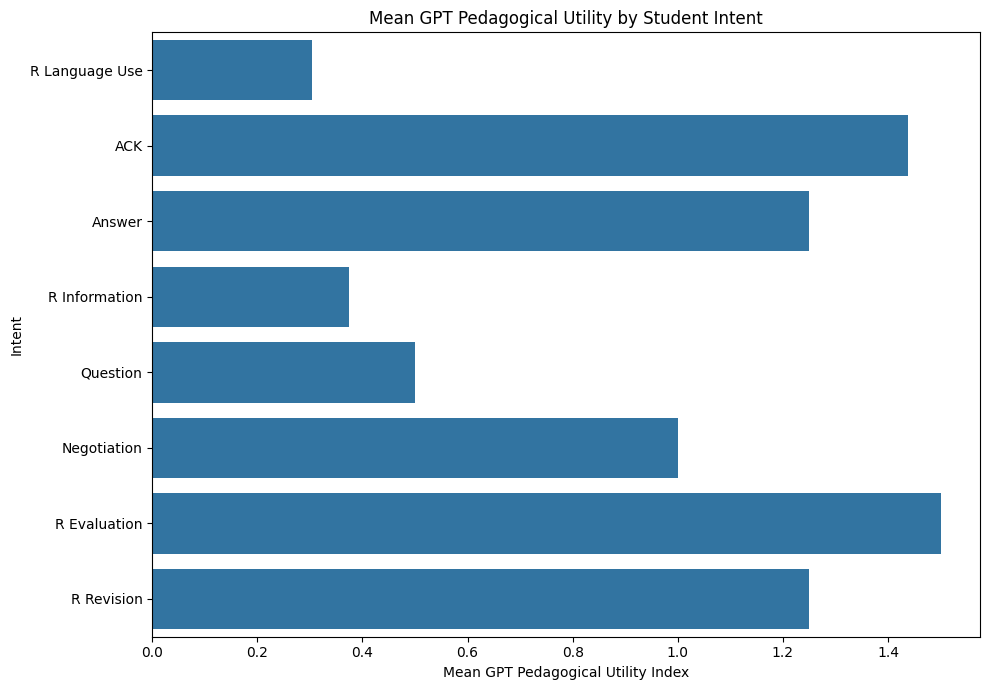

Saved: /content/recipe4u_genai_feedback_outputs/Figure_14_GPT_Pedagogical_Utility_by_Intent.png

Intent-wise GPT Pedagogical Quality Summary


,intent_final,n,mean_rating,edit_rate,mean_clarity,mean_specificity,mean_empathy,mean_srl_support,mean_scaffolding,mean_direct_answer_tendency,mean_dependency_risk,mean_actionability,mean_feedback_depth,mean_positive_quality,mean_dependency_risk_index,mean_pedagogical_utility,mean_srl_scaffolding
6,R Language Use,7,3.7143,0.1429,4.4286,3.1429,3.4286,1.8571,1.8571,2.7143,2.5714,2.4286,1.5714,2.9464,2.6429,0.3036,2.0476
0,ACK,6,4.1667,0.0000,5.0000,2.1667,4.3333,1.8333,1.3333,1.1667,1.6667,1.6667,1.5000,2.8542,1.4167,1.4375,1.6111
1,Answer,5,4.0000,0.6000,3.8000,2.6000,3.8000,2.4000,2.6000,2.0000,1.6000,2.4000,2.0000,3.0500,1.8000,1.2500,2.4667
5,R Information,3,5.0000,0.3333,5.0000,5.0000,4.0000,2.3333,3.0000,4.3333,2.6667,3.6667,3.0000,3.8750,3.5000,0.3750,3.0000
3,Question,1,3.0000,0.0000,4.0000,4.0000,4.0000,2.0000,1.0000,3.0000,2.0000,2.0000,2.0000,3.0000,2.5000,0.5000,1.6667
2,Negotiation,1,5.0000,0.0000,4.0000,3.0000,4.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,3.0000,2.0000,1.0000,2.0000
4,R Evaluation,1,5.0000,1.0000,4.0000,2.0000,4.0000,2.0000,3.0000,1.0000,2.0000,3.0000,1.0000,3.0000,1.5000,1.5000,2.6667
7,R Revision,1,4.0000,0.0000,4.0000,1.0000,4.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.2500,1.0000,1.2500,1.0000


Saved: /content/recipe4u_genai_feedback_outputs/Table_23_Intent_Wise_GPT_Pedagogical_Quality.xlsx


In [59]:
# Cell 50 — Intent-wise GPT pedagogical quality summary

intent_gpt_summary = (
    df_gpt_metrics
    .dropna(subset=["gpt_pedagogical_utility_index"])
    .groupby("intent_final")
    .agg(
        n=("sample_id", "count"),
        mean_rating=("rating_numeric", "mean"),
        edit_rate=("essay_edited_binary", "mean"),
        mean_clarity=("clarity", "mean"),
        mean_specificity=("specificity", "mean"),
        mean_empathy=("empathy", "mean"),
        mean_srl_support=("self_regulation_support", "mean"),
        mean_scaffolding=("scaffolding", "mean"),
        mean_direct_answer_tendency=("direct_answer_tendency", "mean"),
        mean_dependency_risk=("dependency_risk_encouragement", "mean"),
        mean_actionability=("actionability", "mean"),
        mean_feedback_depth=("feedback_depth", "mean"),
        mean_positive_quality=("gpt_positive_feedback_quality_index", "mean"),
        mean_dependency_risk_index=("gpt_dependency_risk_index", "mean"),
        mean_pedagogical_utility=("gpt_pedagogical_utility_index", "mean"),
        mean_srl_scaffolding=("gpt_srl_scaffolding_index", "mean")
    )
    .reset_index()
    .sort_values("n", ascending=False)
    .round(4)
)

# ---- Plot first ----

top_intents_plot = intent_gpt_summary.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_intents_plot,
    y="intent_final",
    x="mean_pedagogical_utility"
)
plt.title("Mean GPT Pedagogical Utility by Student Intent")
plt.xlabel("Mean GPT Pedagogical Utility Index")
plt.ylabel("Intent")
plt.tight_layout()

fig_path = OUTPUT_DIR / "Figure_14_GPT_Pedagogical_Utility_by_Intent.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# ---- Then print tabular values ----

intent_gpt_summary_path = OUTPUT_DIR / "Table_23_Intent_Wise_GPT_Pedagogical_Quality.xlsx"
intent_gpt_summary.to_excel(intent_gpt_summary_path, index=False)

print("\nIntent-wise GPT Pedagogical Quality Summary")
display(intent_gpt_summary.head(30))

print("Saved:", intent_gpt_summary_path)

In [60]:
# Cell 51 — Export all GPT coding tables into one workbook

gpt_combined_path = OUTPUT_DIR / "All_RECIPE4U_GPT_Pedagogical_Coding_Tables.xlsx"

with pd.ExcelWriter(gpt_combined_path, engine="xlsxwriter") as writer:
    gpt_coded_clean.to_excel(writer, sheet_name="GPT_Coded_Rows", index=False)
    gpt_desc_copy.to_excel(writer, sheet_name="T18_GPT_Desc", index=False)
    gpt_corr_matrix.to_excel(writer, sheet_name="T19_GPT_Corr_Matrix")
    gpt_corr_long_unique.to_excel(writer, sheet_name="T19b_GPT_Corr_Long", index=False)
    gpt_edit_compare_table.to_excel(writer, sheet_name="T20_Edit_Comparison", index=False)
    gpt_rating_reg_table.to_excel(writer, sheet_name="T21_Rating_Regression", index=False)
    gpt_logit_table.to_excel(writer, sheet_name="T22_Edit_Logit", index=False)
    intent_gpt_summary.to_excel(writer, sheet_name="T23_Intent_GPT_Summary", index=False)

print("Saved:", gpt_combined_path)

Saved: /content/recipe4u_genai_feedback_outputs/All_RECIPE4U_GPT_Pedagogical_Coding_Tables.xlsx


In [61]:
# Cell 52 — Generate GPT-coding statistical summary

gpt_summary_lines = []

gpt_summary_lines.append("Phase-2 GPT-based pedagogical coding summary")
gpt_summary_lines.append("=" * 60)
gpt_summary_lines.append(f"Rows with GPT pedagogical coding: {df_gpt_metrics['gpt_pedagogical_utility_index'].notna().sum()}")
gpt_summary_lines.append("")

gpt_summary_lines.append("Mean GPT-coded scores:")
for col in gpt_analysis_cols:
    mean_val = df_gpt_metrics[col].mean()
    sd_val = df_gpt_metrics[col].std()
    gpt_summary_lines.append(f"- {col}: mean = {mean_val:.3f}, SD = {sd_val:.3f}")

gpt_summary_lines.append("")
gpt_summary_lines.append("GPT-coded variables significantly different by essay-edit uptake after FDR correction:")

if len(gpt_edit_compare_table) > 0:
    sig_gpt_edit = gpt_edit_compare_table[gpt_edit_compare_table["p_value_fdr"] < 0.05]
else:
    sig_gpt_edit = pd.DataFrame()

if len(sig_gpt_edit) == 0:
    gpt_summary_lines.append("No GPT-coded variables were significant after FDR correction.")
else:
    for _, row in sig_gpt_edit.iterrows():
        gpt_summary_lines.append(
            f"- {row['variable']}: edited mean = {row['edited_mean']:.3f}, "
            f"not-edited mean = {row['not_edited_mean']:.3f}, "
            f"FDR-adjusted {p_text(row['p_value_fdr'])}."
        )

gpt_summary_lines.append("")
gpt_summary_lines.append("Top absolute correlations with rating or essay-edit outcome:")

outcome_corr_subset = gpt_corr_long_unique[
    (
        (gpt_corr_long_unique["variable_1"].isin(["rating_numeric", "essay_edited_binary"])) |
        (gpt_corr_long_unique["variable_2"].isin(["rating_numeric", "essay_edited_binary"]))
    )
].head(20)

for _, row in outcome_corr_subset.iterrows():
    gpt_summary_lines.append(
        f"- {row['variable_1']} vs {row['variable_2']}: "
        f"Spearman rho = {row['spearman_correlation']:.3f}"
    )

gpt_summary_text = "\n".join(gpt_summary_lines)

gpt_summary_path = OUTPUT_DIR / "Phase2_GPT_Pedagogical_Coding_Summary.txt"
with open(gpt_summary_path, "w", encoding="utf-8") as f:
    f.write(gpt_summary_text)

print(gpt_summary_text)
print("\nSaved:", gpt_summary_path)

Phase-2 GPT-based pedagogical coding summary
Rows with GPT pedagogical coding: 25

Mean GPT-coded scores:
- clarity: mean = 4.440, SD = 0.712
- specificity: mean = 2.920, SD = 1.441
- empathy: mean = 3.880, SD = 0.526
- self_regulation_support: mean = 2.000, SD = 0.645
- scaffolding: mean = 2.000, SD = 1.041
- direct_answer_tendency: mean = 2.240, SD = 1.535
- dependency_risk_encouragement: mean = 2.040, SD = 0.935
- actionability: mean = 2.320, SD = 1.069
- feedback_depth: mean = 1.800, SD = 1.000
- non_judgmental_tone: mean = 4.920, SD = 0.277
- gpt_positive_feedback_quality_index: mean = 3.035, SD = 0.579
- gpt_dependency_risk_index: mean = 2.140, SD = 1.168
- gpt_pedagogical_utility_index: mean = 0.895, SD = 1.069
- gpt_srl_scaffolding_index: mean = 2.107, SD = 0.837

GPT-coded variables significantly different by essay-edit uptake after FDR correction:
No GPT-coded variables were significant after FDR correction.

Top absolute correlations with rating or essay-edit outcome:
- empa

In [62]:
# Cell 53 — Download all Phase-1 and Phase-2 outputs as a ZIP file

import shutil
from google.colab import files
from pathlib import Path
import os

OUTPUT_DIR = Path(OUTPUT_DIR)

zip_filename = "/content/RECIPE4U_Phase1_Phase2_All_Publication_Outputs"

if Path(zip_filename + ".zip").exists():
    os.remove(zip_filename + ".zip")

shutil.make_archive(
    base_name=zip_filename,
    format="zip",
    root_dir=OUTPUT_DIR
)

zip_path = zip_filename + ".zip"

print("ZIP file created successfully:")
print(zip_path)

print("\nFiles included:")
for file in sorted(OUTPUT_DIR.glob("*")):
    print("-", file.name)

files.download(zip_path)

ZIP file created successfully:
/content/RECIPE4U_Phase1_Phase2_All_Publication_Outputs.zip

Files included:
- All_RECIPE4U_GPT_Pedagogical_Coding_Tables.xlsx
- All_RECIPE4U_Publication_Tables_Phase1.xlsx
- Figure_10_Readability_Descriptive_Means_SD.png
- Figure_11_GPT_Pedagogical_Score_Means.png
- Figure_12_GPT_Scores_Correlation_Heatmap.png
- Figure_13_GPT_Scores_by_Essay_Edit.png
- Figure_14_GPT_Pedagogical_Utility_by_Intent.png
- Figure_1_Rating_Distribution.png
- Figure_2_Top_Intent_Labels.png
- Figure_3_Correlation_Heatmap.png
- Figure_4_Feedback_Accessibility_by_Essay_Edit.png
- Figure_5_Response_Length_by_Rating.png
- Figure_6_Student_Interaction_Profile_Clusters.png
- Figure_7_Silhouette_Scores_Student_Clusters.png
- Figure_8_Correlations_With_Satisfaction_Rating.png
- Figure_9_Readability_Descriptive_Means.png
- GPT_Pedagogical_Coding_RECIPE4U.xlsx
- GPT_Pedagogical_Coding_RECIPE4U_checkpoint.csv
- GPT_Pedagogical_Coding_With_Indices_RECIPE4U.xlsx
- Phase1_Statistical_Summary.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>